# Midterm NLP

## Data Acquisition

Dalam step ini dilakukan pengumpulan url berita yang berkaitan dengan MBG berdasarkan beberapa keywords tertentu. Setelah pengumpulan url berita dilakukan scraping untuk mengambil content data.

### Import Library

In [21]:
import asyncio
import os
import random
from typing import Optional

import pandas as pd
from tqdm import tqdm
import urllib.parse
import feedparser
from playwright.async_api import Browser, async_playwright
from bs4 import BeautifulSoup

### RSS Fetch

#### Variables Defining

In [41]:
keyword_file = "keyword.txt"
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "articles.csv")
max_concurrent = 10
show_progress = True

limit_per_keyword = 0  # Set to 0 for no limit

In [42]:
class RSSFetchError(Exception):
    pass


def read_keywords(filepath: str) -> list[str]:
    keywords = []
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    keywords.append(line)
        return keywords
    except Exception as e:
        raise RSSFetchError(f"Failed to read keywords from {filepath}: {e}") from e


def fetch_rss_feed(
    keyword: str,
    region: str = "ID",
    language: str = "id",
    limit: int | None = None,
) -> list[dict]:
    safe_keyword = urllib.parse.quote(keyword)
    rss_url = f"https://news.google.com/rss/search?q={safe_keyword}&hl={language}&gl={region}&ceid={region}:{language}"

    try:
        feed = feedparser.parse(rss_url)
    except Exception as e:
        raise RSSFetchError(f"Failed to fetch RSS for '{keyword}': {e}") from e

    entries = feed.entries if limit is None else feed.entries[:limit]
    results = []
    for entry in entries:
        source_title = ""
        source_href = ""
        if hasattr(entry, "source"):
            source_title = entry.source.get("title", "")
            source_href = entry.source.get("href", "")

        results.append(
            {
                "title": getattr(entry, "title", ""),
                "link": getattr(entry, "link", ""),
                "source": source_title,
                "source_url": source_href,
                "pub_date": getattr(entry, "published", ""),  # feedparser maps <pubDate> to entry.published
            }
        )

    return results


def fetch_all_feeds(
    keywords: list[str],
    limit_per_keyword: int | None = None,
    region: str = "ID",
    language: str = "id",
    progress_callback=None,
) -> list[dict]:
    all_entries = []
    for i, keyword in enumerate(keywords):
        if progress_callback:
            progress_callback(i, len(keywords), keyword)
        try:
            entries = fetch_rss_feed(
                keyword, region=region, language=language, limit=limit_per_keyword
            )
            for entry in entries:
                entry["keyword"] = keyword
            all_entries.extend(entries)
        except RSSFetchError as e:
            print(f"[rss_fetcher] Error for '{keyword}': {e}")
    return all_entries

In [43]:
keywords = read_keywords(keyword_file)
print(f"Loaded {len(keywords)} keywords:")
for kw in keywords:
    print(f"  - {kw}")

Loaded 9 keywords:
  - Makan Bergizi Gratis
  - Makan Siang Gratis
  - MBG
  - Program Makan Gratis Pemerintah
  - Badan Gizi Nasional
  - Satuan Pelayanan Pemenuhan Gizi
  - SPPG
  - Perpres Nomor 83 Tahun 2024
  - Perpres Nomor 115 Tahun 2025


In [44]:
# Step 1: Fetch RSS feeds
_limit = None if limit_per_keyword == 0 else limit_per_keyword

all_entries = []
for keyword in tqdm(keywords, desc="Fetching RSS feeds", disable=not show_progress):
    entries = fetch_rss_feed(keyword, limit=_limit)
    for entry in entries:
        entry["keyword"] = keyword
    all_entries.extend(entries)

print(f"\nTotal entries fetched: {len(all_entries)}")

# Deduplicate by Google redirect URL
seen_links = set()
unique_entries = []
for entry in all_entries:
    if entry["link"] not in seen_links:
        seen_links.add(entry["link"])
        unique_entries.append(entry)

print(f"Unique entries after dedup: {len(unique_entries)}")

Fetching RSS feeds: 100%|██████████| 9/9 [00:10<00:00,  1.13s/it]


Total entries fetched: 910
Unique entries after dedup: 797


### URL Resolution

In [45]:
class URLResolutionError(Exception):
    pass


class RateLimiter:
    def __init__(self, min_delay: float, max_delay: float):
        self.min_delay = min_delay
        self.max_delay = max_delay

    async def wait(self):
        delay = random.uniform(self.min_delay, self.max_delay)
        await asyncio.sleep(delay)


class ExponentialBackoff:
    def __init__(self, max_retries: int, base_delay: float = 1.0):
        self.max_retries = max_retries
        self.base_delay = base_delay

    async def execute_with_retry(self, func, *args, **kwargs):
        last_exc = None
        for attempt in range(self.max_retries):
            try:
                return await func(*args, **kwargs)
            except Exception as e:
                last_exc = e
                if attempt < self.max_retries - 1:
                    wait_time = (2 ** attempt) * self.base_delay + random.uniform(0, 1)
                    await asyncio.sleep(wait_time)
        raise URLResolutionError(f"All {self.max_retries} retries failed: {last_exc}") from last_exc


class URLResolver:
    def __init__(
        self,
        headless: bool = True,
        max_concurrent: int = 5,
        min_delay: float = 1.0,
        max_delay: float = 3.0,
        max_retries: int = 3,
        timeout: int = 30000,
    ):
        self.headless = headless
        self.max_concurrent = max_concurrent
        self.timeout = timeout
        self._rate_limiter = RateLimiter(min_delay, max_delay)
        self._backoff = ExponentialBackoff(max_retries)
        self._playwright = None
        self._browser: Optional[Browser] = None
        self._semaphore: Optional[asyncio.Semaphore] = None

    async def __aenter__(self) -> "URLResolver":
        self._playwright = await async_playwright().start()
        self._browser = await self._playwright.chromium.launch(headless=self.headless)
        self._semaphore = asyncio.Semaphore(self.max_concurrent)
        return self

    async def __aexit__(self, exc_type, exc_val, exc_tb):
        await self.close()

    async def close(self):
        if self._browser:
            await self._browser.close()
            self._browser = None
        if self._playwright:
            await self._playwright.stop()
            self._playwright = None

    async def _do_resolve(self, redirect_url: str) -> tuple[str, Optional[str]]:
        context = await self._browser.new_context(
            user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
        )
        try:
            page = await context.new_page()
            await self._rate_limiter.wait()
            await page.goto(redirect_url, wait_until="domcontentloaded", timeout=self.timeout)
            # Google News uses JS to redirect — wait for the URL to leave news.google.com
            if "news.google.com" in page.url:
                try:
                    await page.wait_for_url(
                        lambda url: "news.google.com" not in url,
                        timeout=15000,
                    )
                except Exception:
                    pass  # URL didn't change; keep whatever we have
            final_url = page.url
            html_content = await page.content()
            return final_url, html_content
        finally:
            await context.close()

    async def resolve_url(self, redirect_url: str) -> tuple[str, Optional[str]]:
        async with self._semaphore:
            return await self._backoff.execute_with_retry(self._do_resolve, redirect_url)

    async def resolve_batch(
        self,
        urls: list[str],
        progress_callback=None,
    ) -> list[tuple[str, Optional[str]]]:
        completed = 0
        total = len(urls)
        results = [None] * total
        lock = asyncio.Lock()

        async def resolve_one(i: int, url: str):
            nonlocal completed
            try:
                result = await self.resolve_url(url)
            except URLResolutionError as e:
                result = (url, None)
                print(f"[url_resolver] Failed to resolve {url}: {e}")
            results[i] = result
            async with lock:
                completed += 1
                if progress_callback:
                    await progress_callback(total, completed, url)

        await asyncio.gather(*[resolve_one(i, url) for i, url in enumerate(urls)])
        return results

In [46]:
# Step 2: Resolve redirect URLs with Playwright
redirect_urls = [e["link"] for e in unique_entries]

with tqdm(total=len(redirect_urls), desc="Resolving URLs", disable=not show_progress) as pbar:
    async def _url_progress(total, completed, url):
        pbar.n = completed
        pbar.set_postfix_str(url[:50])
        pbar.refresh()

    async with URLResolver(max_concurrent=max_concurrent) as resolver:
        resolved = await resolver.resolve_batch(redirect_urls, _url_progress)

print(f"Resolved {len(resolved)} URLs")

Resolving URLs:  19%|█▉        | 154/797 [05:09<21:33,  2.01s/it, https://news.google.com/rss/articles/CBMi0gFBVV95c]

[url_resolver] Failed to resolve https://news.google.com/rss/articles/CBMi0gFBVV95cUxQNGE5N3dzejR2SllrZmFsV3NWMFRzX2E1WFJHV3JKLXZSYldBQnZKZXByalhYa1Q4ems4RDlZYWhJUXIyRWdSZ1B0ekJrZk5vd2Z3aERBTlk3UVVGQm5rLWw1VF8ydkdpTEZQZUZSd2YzQjN1aU1UaU8yV2hObEhpdDBxNXBzY29Lc0pYR1dSRGptR096SDlaem1yOGtwUG50NlpFaURiRFprOVV4Z0FOX0stanRIcUNCbEFsMVk2ZTBZRXVqN25NUkZIbl9OblFOZ1E?oc=5: All 3 retries failed: Page.content: Unable to retrieve content because the page is navigating and changing the content.


Resolving URLs:  20%|██        | 161/797 [05:31<21:50,  2.06s/it, https://news.google.com/rss/articles/CBMiqwFBVV95c]

[url_resolver] Failed to resolve https://news.google.com/rss/articles/CBMiqwFBVV95cUxQRm9vdHpiMUZnRzlBTk1rUXdfUWJyVGVHZzNDUHJBdGE5U2N6ZWduVTJ2NE1qWktFYkdYZWNvT2tjSEZDTFdzdHdWc1lzclZ6TjZWSU94a3FsbDBPcWhXNHhuWXJPZlBmenQ5UkVsWWdBeGZtM2F4Q3ZNdm43a3FmM2ZZN1NYbEEzSWhZLVJUY0RUTnJKckFhQ1Jhc1dqYlhUWFdBdGZFUHNhdjg?oc=5: All 3 retries failed: Page.content: Unable to retrieve content because the page is navigating and changing the content.


Resolving URLs:  21%|██        | 164/797 [05:37<21:40,  2.06s/it, https://news.google.com/rss/articles/CBMia0FVX3lxT]

...

[url_resolver] Failed to resolve https://news.google.com/rss/articles/CBMipwFBVV95cUxPaVYteVRFR3RRbjE0WWFrbWpqUmdvc0JVVGY5aTVlUjNKWUYxUDQ0Rk9SOHN3cE5PcFBFS2tObWVQNGE1djJ6R1dRNS1wV3gzMV9QYW0zSXZ3TWZ5MHJaV2RTSENtdnI3cVFoSVkzRTRJX1kwa2k1U1BWSUxRNFM4X2pjX2RYcTBCbTE3TElkOWEybjJmTzBqX3Y0Nk9LS3QtNXpnelc1UQ?oc=5: All 3 retries failed: Page.content: Unable to retrieve content because the page is navigating and changing the content.


Resolving URLs:  97%|█████████▋| 772/797 [25:15<00:49,  1.96s/it, https://news.google.com/rss/articles/CBMiwgFBVV95c]

[url_resolver] Failed to resolve https://news.google.com/rss/articles/CBMiwgFBVV95cUxOeWZPQXFMeEhZUWR5YXF3TXl3TnoyRlhWaVN0Q2pUdTFBMHdMVUF0YTEtc1pfczFybW1QZEdYb1BrMjZBWFkzYmNvNDdyWXB0Ykh4UmxxT251d0t0U3d4djItRE1ZbE1kRG9mUkw1VjJuLVVuQUppUk1xcEZMQVhQOU1uVWU3ZUVXMVNsVlI4YllBemYyS0p6VGhPR0FiM0U4dXN1NnR1ZWJFc0xXLWNGZkRNUnlIYjhvTGp4UXZYQUNLQQ?oc=5: All 3 retries failed: Page.content: Unable to retrieve content because the page is navigating and changing the content.


Resolving URLs: 100%|██████████| 797/797 [27:33<00:00,  2.07s/it, https://news.google.com/rss/articles/CBMif0FVX3lxT]

[url_resolver] Failed to resolve https://news.google.com/rss/articles/CBMif0FVX3lxTFBXVlhIQWlBdmY5emJDWm5GRkUzdkNQbXlqUVA3VG9GVGpGMnhQWFJkN1RkcF9iSnhKSUxzXzRENlM4T0J2ejV6VTJkczFXUmZ1T3VEbElKSDVQTjgwWDkySWNMc0U4SXFsWjAxTHhBRjh5WUZieWNNanZxdXU5NWM?oc=5: All 3 retries failed: Page.content: Unable to retrieve content because the page is navigating and changing the content.
Resolved 797 URLs


### Article Parsing

In [47]:
def parse_article_bs4(html_content: Optional[str], url: str) -> dict:
    if not html_content:
        return {"title": "", "text": "NO_CONTENT_EXTRACTED", "pub_date": None, "authors": []}

    try:
        soup = BeautifulSoup(html_content, "html.parser")

        for tag in soup(["script", "style", "nav", "footer", "header", "aside", "iframe"]):
            tag.decompose()

        # Title
        title = ""
        h1 = soup.find("h1")
        if h1:
            title = h1.get_text(strip=True)
        elif soup.title:
            title = soup.title.get_text(strip=True)

        # Published date from common meta tags
        pub_date = None
        for attrs in [
            {"property": "article:published_time"},
            {"name": "article:published_time"},
            {"name": "publishedDate"},
            {"name": "date"},
            {"itemprop": "datePublished"},
        ]:
            meta = soup.find("meta", attrs)
            if meta and meta.get("content"):
                pub_date = meta["content"]
                break

        # Authors
        authors = []
        author_meta = soup.find("meta", {"name": "author"})
        if author_meta and author_meta.get("content"):
            authors.append(author_meta["content"])
        if not authors:
            for tag in soup.find_all(attrs={"rel": "author"}):
                text = tag.get_text(strip=True)
                if text:
                    authors.append(text)
        if not authors:
            for tag in soup.find_all(attrs={"itemprop": "author"}):
                text = tag.get_text(strip=True)
                if text:
                    authors.append(text)

        # Main text: prefer <article>, then <main>, fall back to <body>
        container = soup.find("article") or soup.find("main") or soup.find("body")
        paragraphs = container.find_all("p") if container else soup.find_all("p")
        text = "\n".join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))

        return {
            "title": title,
            "text": text or "NO_CONTENT_EXTRACTED",
            "pub_date": pub_date,
            "authors": authors,
        }
    except Exception as e:
        return {"title": "", "text": f"FAILED_TO_PARSE: {e}", "pub_date": None, "authors": []}

In [48]:
# Step 3: Parse articles with BeautifulSoup
rows = []
skipped_url = 0
skipped_content = 0

parse_iter = tqdm(
    zip(unique_entries, resolved),
    total=len(unique_entries),
    desc="Parsing articles",
    disable=not show_progress,
)
for entry, (final_url, html_content) in parse_iter:
    if "news.google.com" in final_url:
        skipped_url += 1
        continue

    parsed = parse_article_bs4(html_content, final_url)

    if parsed["text"] in ("NO_CONTENT_EXTRACTED",) or parsed["text"].startswith("FAILED_TO_PARSE"):
        skipped_content += 1
        continue

    rows.append({
        "keyword": entry["keyword"],
        "judul": entry["title"],
        "tanggal": entry["pub_date"],
        "sumber": entry["source"],
        "source_url": entry["source_url"],
        "url_google": entry["link"],
        "url_resolved": final_url,
        "konten": parsed["text"],
        "authors": ", ".join(parsed["authors"]),
    })

print(f"Skipped {skipped_url} unresolved (still news.google.com)")
print(f"Skipped {skipped_content} with no extractable content")

# Step 4: Save to CSV
df = pd.DataFrame(rows)
df = df.drop_duplicates(subset=["url_resolved"])
df.to_csv(output_file, index=False)
print(f"\nDone! {len(df)} unique articles saved to {output_file}")
df

Parsing articles: 100%|██████████| 797/797 [00:28<00:00, 27.49it/s]

Skipped 9 unresolved (still news.google.com)
Skipped 188 with no extractable content

Done! 599 unique articles saved to output/articles.csv


,keyword,judul,tanggal,sumber,source_url,url_google,url_resolved,konten,authors
0,Makan Bergizi Gratis,Kampus diminta 'terlibat aktif' bangun dapur M...,"Fri, 01 May 2026 07:39:41 GMT",BBC,https://www.bbc.com,https://news.google.com/rss/articles/CBMiYEFVX...,https://www.bbc.com/indonesia/articles/c5y8jyg...,"Sumber gambar,ANTARA FOTO/Adeng Bustomi\nKeter...",
1,Makan Bergizi Gratis,"Dukung Kampus Punya Dapur MBG, Mendiktisaintek...","Sat, 02 May 2026 12:37:00 GMT",Medcom.id,https://www.medcom.id,https://news.google.com/rss/articles/CBMi1gFBV...,https://www.medcom.id/pendidikan/news-pendidik...,Ikuti media sosial medcom.id dan dapatkan berb...,medcom.id developer
2,Makan Bergizi Gratis,Mendikti Minta Kampus Lain Tiru Langkah Unhas ...,"Thu, 30 Apr 2026 03:03:43 GMT",Tempo.co,https://www.tempo.co,https://news.google.com/rss/articles/CBMioAFBV...,https://www.tempo.co/politik/mendikti-minta-ka...,"MENTERI Pendidikan Tinggi, Sains, dan Teknolog...",
3,Makan Bergizi Gratis,Program makan bergizi di Jambi sentuh 446.087 ...,"Sat, 02 May 2026 11:47:23 GMT",ANTARA News Jambi,https://jambi.antaranews.com,https://news.google.com/rss/articles/CBMipwFBV...,https://jambi.antaranews.com/berita/655860/pro...,Kota Jambi (ANTARA) - Program Makan Bergizi Gr...,ANTARA News Agency
4,Makan Bergizi Gratis,Menagih Mutu Pendidikan Setelah Disedot MBG - ...,"Sat, 02 May 2026 09:33:00 GMT",Kompas.id,https://www.kompas.id,https://news.google.com/rss/articles/CBMifkFVX...,https://www.kompas.id/artikel/menagih-mutu-pen...,Program Makan Bergizi Gratis (MBG) yang digada...,Stephanus Aranditio - stephanus.aranditio@komp...
...,...,...,...,...,...,...,...,...,...
595,Perpres Nomor 115 Tahun 2025,"BGN: Semua Guru, Tenaga Kebersihan hingga Staf...","Thu, 08 Jan 2026 08:00:00 GMT",Liputan6.com,https://www.liputan6.com,https://news.google.com/rss/articles/CBMitwFBV...,https://www.liputan6.com/news/read/6252989/bgn...,"Liputan6.com, Jakarta -Badan Gizi Nasional (BG...",Liputan6.com
596,Perpres Nomor 115 Tahun 2025,"BGN Larang SPPG Tolak Produk UMKM, Petani, dan...","Tue, 27 Jan 2026 08:00:00 GMT",JPNN.com Jatim,https://jatim.jpnn.com,https://news.google.com/rss/articles/CBMipAFBV...,https://jatim.jpnn.com/jatim-terkini/42922/bgn...,"jatim.jpnn.com, BONDOWOSO - Setiap Satuan Pela...",
597,Perpres Nomor 115 Tahun 2025,Dapur MBG Dilarang Tolak Pasokan UMKM hingga P...,"Wed, 28 Jan 2026 08:00:00 GMT","detikFinance - Berita Ekonomi Bisnis, dan Inve...",https://finance.detik.com,https://news.google.com/rss/articles/CBMiwAFBV...,https://finance.detik.com/berita-ekonomi-bisni...,Badan Gizi Nasional (BGN) menegaskan Satuan Pe...,Retno Ayuningrum
598,Perpres Nomor 115 Tahun 2025,"Anak Jalanan hingga Lansia Bakal dapat MBG, Be...","Sat, 06 Dec 2025 08:00:00 GMT",Tempo.co,https://www.tempo.co,https://news.google.com/rss/articles/CBMioAFBV...,https://www.tempo.co/politik/anak-jalanan-hing...,BADAN Gizi Nasional atau BGN mengungkapkan ana...,


## DATA PREPROCESSING

Dalam step ini akan dilakukan beberapa langkah preprocessing pada kolom `konten` artikel berita MBG, meliputi:
1. **Uppercase to Lowercase** — normalisasi teks
2. **Stopwords Removal** — penghapusan kata-kata tidak bermakna (NLTK + custom)
3. **Lemmatization** — pemotongan ke kata dasar menggunakan PySastrawi

> ⚠️ Section ini **independen** — membaca langsung dari `output/articles.csv`, tidak bergantung pada variabel dari Data Acquisition.

### Import Library & Load Data

In [49]:
import pandas as pd
import re
import nltk
from collections import Counter
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Download NLTK Indonesian stopwords (run once)
nltk.download('stopwords', quiet=True)

# Load dataset independently from articles.csv
df = pd.read_csv('output/articles.csv')
print(f'Dataset loaded: {len(df)} articles')
print(f'Columns: {list(df.columns)}')
df.head(3)

Dataset loaded: 599 articles
Columns: ['keyword', 'judul', 'tanggal', 'sumber', 'source_url', 'url_google', 'url_resolved', 'konten', 'authors']


,keyword,judul,tanggal,sumber,source_url,url_google,url_resolved,konten,authors
0,Makan Bergizi Gratis,Kampus diminta 'terlibat aktif' bangun dapur M...,"Fri, 01 May 2026 07:39:41 GMT",BBC,https://www.bbc.com,https://news.google.com/rss/articles/CBMiYEFVX...,https://www.bbc.com/indonesia/articles/c5y8jyg...,"Sumber gambar,ANTARA FOTO/Adeng Bustomi\nKeter...",NaN
1,Makan Bergizi Gratis,"Dukung Kampus Punya Dapur MBG, Mendiktisaintek...","Sat, 02 May 2026 12:37:00 GMT",Medcom.id,https://www.medcom.id,https://news.google.com/rss/articles/CBMi1gFBV...,https://www.medcom.id/pendidikan/news-pendidik...,Ikuti media sosial medcom.id dan dapatkan berb...,medcom.id developer
2,Makan Bergizi Gratis,Mendikti Minta Kampus Lain Tiru Langkah Unhas ...,"Thu, 30 Apr 2026 03:03:43 GMT",Tempo.co,https://www.tempo.co,https://news.google.com/rss/articles/CBMioAFBV...,https://www.tempo.co/politik/mendikti-minta-ka...,"MENTERI Pendidikan Tinggi, Sains, dan Teknolog...",NaN


---
### Uppercase to Lowercase

Konversi seluruh teks `konten` ke huruf kecil. Hasilnya disimpan di kolom baru `to_lowercase`.

In [50]:
def to_lowercase(text: str) -> str:
    if not isinstance(text, str):
        return ''
    return text.lower()

df['to_lowercase'] = df['konten'].apply(to_lowercase)

print('=== Sample: Original konten ===')
print(df['konten'].iloc[0][:300])
print('\n=== Sample: After Lowercase ===')
print(df['to_lowercase'].iloc[0][:300])

=== Sample: Original konten ===
Sumber gambar,ANTARA FOTO/Adeng Bustomi
Keterlibatan perguruan tinggi dalam program makan bergizi gratis dianggap sebagai upaya "membungkam suara-suara kritis" terhadap proyek yang dianggap bermasalah ini.
Sebelumnya, Menteri Pendidikan Tinggi Riset dan Teknologi, Brian Yuliarto, mengatakan kampus h

=== Sample: After Lowercase ===
sumber gambar,antara foto/adeng bustomi
keterlibatan perguruan tinggi dalam program makan bergizi gratis dianggap sebagai upaya "membungkam suara-suara kritis" terhadap proyek yang dianggap bermasalah ini.
sebelumnya, menteri pendidikan tinggi riset dan teknologi, brian yuliarto, mengatakan kampus h


---
### Stopwords Removal

Langkah ini terdiri dari:
- Tokenisasi & pembersihan tanda baca / angka
- Penghapusan stopwords NLTK Bahasa Indonesia
- Menampilkan **top 100 kata** paling sering muncul *sebelum* custom stopwords → pilih secara manual
- Penambahan **custom stopwords** secara manual
- Penerapan stopwords final → kolom `before_stopwords` dan `after_stopwords`

In [51]:
def clean_and_tokenize(text: str) -> list:
    """Lowercase -> remove non-alphabetic -> tokenize"""
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if len(t) > 1]  # drop single chars
    return tokens

# before_stopwords: cleaned tokens, NOT filtered yet
df['before_stopwords'] = df['to_lowercase'].apply(clean_and_tokenize)

print('Sample tokens (before stopwords):')
print(df['before_stopwords'].iloc[0][:30])

Sample tokens (before stopwords):
['sumber', 'gambar', 'antara', 'foto', 'adeng', 'bustomi', 'keterlibatan', 'perguruan', 'tinggi', 'dalam', 'program', 'makan', 'bergizi', 'gratis', 'dianggap', 'sebagai', 'upaya', 'membungkam', 'suara', 'suara', 'kritis', 'terhadap', 'proyek', 'yang', 'dianggap', 'bermasalah', 'ini', 'sebelumnya', 'menteri', 'pendidikan']


In [52]:
# Round 1: Apply only NLTK stopwords, then inspect top 100
nltk_stopwords = set(stopwords.words('indonesian'))

def remove_stopwords(tokens: list, sw_set: set) -> list:
    return [t for t in tokens if t not in sw_set]

tokens_after_nltk = df['before_stopwords'].apply(lambda t: remove_stopwords(t, nltk_stopwords))

all_tokens_r1 = [token for tokens in tokens_after_nltk for token in tokens]
freq_r1 = Counter(all_tokens_r1)
top100_r1 = pd.DataFrame(freq_r1.most_common(100), columns=['kata', 'frekuensi'])

print('=== TOP 100 KATA (setelah NLTK stopwords) ===')
print('Perhatikan kata-kata yang masih tidak bermakna untuk ditambahkan ke custom stopwords.\n')
# top100_r1
print(top100_r1.to_string())

=== TOP 100 KATA (setelah NLTK stopwords) ===
Perhatikan kata-kata yang masih tidak bermakna untuk ditambahkan ke custom stopwords.

            kata  frekuensi
0        program       3137
1            mbg       2645
2           gizi       2548
3           sppg       1901
4       nasional       1490
5          makan       1398
6        bergizi       1322
7         gratis       1221
8     pemerintah       1216
9           anak       1193
10           bgn       1061
11         badan       1058
12       makanan       1010
13    pendidikan        940
14        kepala        921
15      presiden        913
16      anggaran        889
17     indonesia        840
18         dapur        831
19    masyarakat        829
20            rp        817
21       sekolah        808
22        pangan        797
23     pemenuhan        757
24        daerah        617
25     pelayanan        558
26        negara        554
27      penerima        548
28   pelaksanaan        548
29     kesehatan        530

In [53]:
# ✏️  EDIT THIS CELL — tambahkan kata yang ingin dihapus berdasarkan top 100 di atas
custom_stopwords = [
    # Noise words from scraping
    'baca', 'juga', 'klik', 'sini', 'scroll', 'advertisement', 'loading',
    'share', 'now', 'terkait', 'lainnya', 'akhir', 'content', 'brandzview',
    'news', 'bola', 'travel', 'regional', 'tekno', 'properti',
    # Common filler words in Indonesian news articles
    'kata', 'ujar', 'ucap', 'tutur', 'sebut', 'ungkap', 'tegas', 'tambah',
    'jelaskan', 'sampaikan',
    # Abbreviations / boilerplate
    'rp', 'pt', 'ri', 'no', 'st',
    # Custom
    'bgn', 'mbg', 'dadan', 'yangadasppg', 'jumlahsppg', 'jumlahsupplier',
    'news', 'baca', 'ditutup', 'nomor', 'isu', 'rp', 'juta', 'kab',
    'memiliki', 'mendukung', 'terkait', 'berdasarkan', 'utama', 'langsung',
    'analisis', 'rekomendasi', 'perkembangan', 'saudara' ,
    'implementasi', 'pelaksanaan', 'keterlibatan', 'mengalami', 'menilai', 
    'sesuai', 'dianggap', 'pengembangan', 'sumber', 'satuan', 'bidang', 
    'unit', 'langkah', 'daya', 'sektor', 'sistem', 'gambar', 'alim', 'hindayana'
]

print(f'Custom stopwords ditambahkan: {len(custom_stopwords)} kata')
print(custom_stopwords)

Custom stopwords ditambahkan: 78 kata
['baca', 'juga', 'klik', 'sini', 'scroll', 'advertisement', 'loading', 'share', 'now', 'terkait', 'lainnya', 'akhir', 'content', 'brandzview', 'news', 'bola', 'travel', 'regional', 'tekno', 'properti', 'kata', 'ujar', 'ucap', 'tutur', 'sebut', 'ungkap', 'tegas', 'tambah', 'jelaskan', 'sampaikan', 'rp', 'pt', 'ri', 'no', 'st', 'bgn', 'mbg', 'dadan', 'yangadasppg', 'jumlahsppg', 'jumlahsupplier', 'news', 'baca', 'ditutup', 'nomor', 'isu', 'rp', 'juta', 'kab', 'memiliki', 'mendukung', 'terkait', 'berdasarkan', 'utama', 'langsung', 'analisis', 'rekomendasi', 'perkembangan', 'saudara', 'implementasi', 'pelaksanaan', 'keterlibatan', 'mengalami', 'menilai', 'sesuai', 'dianggap', 'pengembangan', 'sumber', 'satuan', 'bidang', 'unit', 'langkah', 'daya', 'sektor', 'sistem', 'gambar', 'alim', 'hindayana']


In [54]:
# Combine NLTK + custom stopwords
final_stopwords = nltk_stopwords.union(set(custom_stopwords))
print(f'Total stopwords (NLTK + custom): {len(final_stopwords)}')

# Apply final stopwords -> after_stopwords
df['after_stopwords'] = df['before_stopwords'].apply(
    lambda tokens: remove_stopwords(tokens, final_stopwords)
)

print('\n=== Sample: before_stopwords ===')
print(df['before_stopwords'].iloc[0][:20])
print('\n=== Sample: after_stopwords ===')
print(df['after_stopwords'].iloc[0][:20])

Total stopwords (NLTK + custom): 817

=== Sample: before_stopwords ===
['sumber', 'gambar', 'antara', 'foto', 'adeng', 'bustomi', 'keterlibatan', 'perguruan', 'tinggi', 'dalam', 'program', 'makan', 'bergizi', 'gratis', 'dianggap', 'sebagai', 'upaya', 'membungkam', 'suara', 'suara']

=== Sample: after_stopwords ===
['foto', 'adeng', 'bustomi', 'perguruan', 'program', 'makan', 'bergizi', 'gratis', 'upaya', 'membungkam', 'suara', 'suara', 'kritis', 'proyek', 'bermasalah', 'menteri', 'pendidikan', 'riset', 'teknologi', 'brian']


In [55]:
# Top 100 words after full stopwords removal
all_tokens_final = [token for tokens in df['after_stopwords'] for token in tokens]
freq_final = Counter(all_tokens_final)
top100_after_sw = pd.DataFrame(freq_final.most_common(100), columns=['kata', 'frekuensi'])

print('=== TOP 100 KATA (setelah NLTK + custom stopwords) ===')
# top100_after_sw
print(top100_after_sw.to_string())

=== TOP 100 KATA (setelah NLTK + custom stopwords) ===
            kata  frekuensi
0        program       3137
1           gizi       2548
2           sppg       1901
3       nasional       1490
4          makan       1398
5        bergizi       1322
6         gratis       1221
7     pemerintah       1216
8           anak       1193
9          badan       1058
10       makanan       1010
11    pendidikan        940
12        kepala        921
13      presiden        913
14      anggaran        889
15     indonesia        840
16         dapur        831
17    masyarakat        829
18       sekolah        808
19        pangan        797
20     pemenuhan        757
21        daerah        617
22     pelayanan        558
23        negara        554
24      penerima        548
25     kesehatan        530
26       manfaat        513
27         siswa        495
28       prabowo        488
29      kualitas        441
30     kabupaten        438
31       wilayah        429
32       jakarta     

---
### Lemmatization (Stemming ke Kata Dasar)

Menggunakan **PySastrawi** untuk mereduksi kata ke bentuk dasarnya (*kata dasar*). Hasilnya disimpan di kolom `after_lemmatization`.

In [56]:
# Initialize Sastrawi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def lemmatize_tokens(tokens: list) -> list:
    return [stemmer.stem(t) for t in tokens]

print('Running lemmatization (Sastrawi)... This may take a moment.')
df['after_lemmatization'] = df['after_stopwords'].apply(lemmatize_tokens)

print('Done!')
print('\n=== Sample: after_stopwords ===')
print(df['after_stopwords'].iloc[0][:15])
print('\n=== Sample: after_lemmatization ===')
print(df['after_lemmatization'].iloc[0][:15])

Running lemmatization (Sastrawi)... This may take a moment.
Done!

=== Sample: after_stopwords ===
['foto', 'adeng', 'bustomi', 'perguruan', 'program', 'makan', 'bergizi', 'gratis', 'upaya', 'membungkam', 'suara', 'suara', 'kritis', 'proyek', 'bermasalah']

=== Sample: after_lemmatization ===
['foto', 'adeng', 'bustomi', 'guru', 'program', 'makan', 'gizi', 'gratis', 'upaya', 'bungkam', 'suara', 'suara', 'kritis', 'proyek', 'masalah']


---
### Word Count (n) Before & After Stopwords

In [57]:
df['n_before_stopwords'] = df['before_stopwords'].apply(len)
df['n_after_stopwords']  = df['after_stopwords'].apply(len)

avg_before = df['n_before_stopwords'].mean()
avg_after  = df['n_after_stopwords'].mean()
avg_reduction = (1 - df['n_after_stopwords'] / df['n_before_stopwords']).mean() * 100

print('=== Word Count per Article ===')
print(df[['judul', 'n_before_stopwords', 'n_after_stopwords']].to_string())
print(f'\nAverage tokens before stopwords : {avg_before:.1f}')
print(f'Average tokens after  stopwords : {avg_after:.1f}')
print(f'Average reduction               : {avg_reduction:.1f}%')

=== Word Count per Article ===
                                                                                                                                                                                                                                          judul  n_before_stopwords  n_after_stopwords
0                                                                                                                                                                     Kampus diminta 'terlibat aktif' bangun dapur MBG, bagi-bagi proyek? - BBC                1949                958
1                                                                                                                                               Dukung Kampus Punya Dapur MBG, Mendiktisaintek: Sivitas Akademika Harus Ambil Peran - Medcom.id                   9                  7
2                                                                                                                                   

---
### Top 100 Frequency Words (After Lemmatization)

In [58]:
all_lemma_tokens = [token for tokens in df['after_lemmatization'] for token in tokens]
freq_lemma = Counter(all_lemma_tokens)
top100_lemma = pd.DataFrame(freq_lemma.most_common(100), columns=['kata_dasar', 'frekuensi'])

print('=== TOP 100 KATA DASAR (setelah lemmatization) ===')
top100_lemma

=== TOP 100 KATA DASAR (setelah lemmatization) ===


,kata_dasar,frekuensi
0,gizi,3894
1,program,3153
2,makan,2489
3,sppg,1901
4,nasional,1491
...,...,...
95,ada,237
96,susu,237
97,tuju,235
98,pasok,232


---
### Export: articles_preprocessed.csv

In [59]:
import os

# Convert list columns to space-separated strings for CSV storage
df_out = df.copy()
df_out['before_stopwords']    = df_out['before_stopwords'].apply(lambda t: ' '.join(t))
df_out['after_stopwords']     = df_out['after_stopwords'].apply(lambda t: ' '.join(t))
df_out['after_lemmatization'] = df_out['after_lemmatization'].apply(lambda t: ' '.join(t))

# Column order: original raw columns + new preprocessing columns
original_cols = ['keyword', 'judul', 'tanggal', 'sumber', 'source_url',
                 'url_google', 'url_resolved', 'konten', 'authors']
new_cols = ['to_lowercase', 'before_stopwords', 'n_before_stopwords',
            'after_stopwords', 'n_after_stopwords', 'after_lemmatization']

df_out = df_out[original_cols + new_cols]

output_path = os.path.join('output', 'articles_preprocessed.csv')
df_out.to_csv(output_path, index=False)

print(f'Saved {len(df_out)} rows -> {output_path}')
print(f'Columns: {list(df_out.columns)}')
df_out.head(3)

Saved 599 rows -> output/articles_preprocessed.csv
Columns: ['keyword', 'judul', 'tanggal', 'sumber', 'source_url', 'url_google', 'url_resolved', 'konten', 'authors', 'to_lowercase', 'before_stopwords', 'n_before_stopwords', 'after_stopwords', 'n_after_stopwords', 'after_lemmatization']


,keyword,judul,tanggal,sumber,source_url,url_google,url_resolved,konten,authors,to_lowercase,before_stopwords,n_before_stopwords,after_stopwords,n_after_stopwords,after_lemmatization
0,Makan Bergizi Gratis,Kampus diminta 'terlibat aktif' bangun dapur M...,"Fri, 01 May 2026 07:39:41 GMT",BBC,https://www.bbc.com,https://news.google.com/rss/articles/CBMiYEFVX...,https://www.bbc.com/indonesia/articles/c5y8jyg...,"Sumber gambar,ANTARA FOTO/Adeng Bustomi\nKeter...",NaN,"sumber gambar,antara foto/adeng bustomi\nketer...",sumber gambar antara foto adeng bustomi keterl...,1949,foto adeng bustomi perguruan program makan ber...,958,foto adeng bustomi guru program makan gizi gra...
1,Makan Bergizi Gratis,"Dukung Kampus Punya Dapur MBG, Mendiktisaintek...","Sat, 02 May 2026 12:37:00 GMT",Medcom.id,https://www.medcom.id,https://news.google.com/rss/articles/CBMi1gFBV...,https://www.medcom.id/pendidikan/news-pendidik...,Ikuti media sosial medcom.id dan dapatkan berb...,medcom.id developer,ikuti media sosial medcom.id dan dapatkan berb...,ikuti media sosial medcom id dan dapatkan berb...,9,ikuti media sosial medcom id dapatkan keuntungan,7,ikut media sosial medcom id dapat untung
2,Makan Bergizi Gratis,Mendikti Minta Kampus Lain Tiru Langkah Unhas ...,"Thu, 30 Apr 2026 03:03:43 GMT",Tempo.co,https://www.tempo.co,https://news.google.com/rss/articles/CBMioAFBV...,https://www.tempo.co/politik/mendikti-minta-ka...,"MENTERI Pendidikan Tinggi, Sains, dan Teknolog...",NaN,"menteri pendidikan tinggi, sains, dan teknolog...",menteri pendidikan tinggi sains dan teknologi ...,257,menteri pendidikan sains teknologi brian yulia...,128,menteri didik sains teknologi brian yuliarto k...


## TF-IDF Analysis

Section ini **independen** — membaca langsung dari `output/articles_preprocessed.csv`.

Analisis TF-IDF dilakukan berdasarkan:
1. **Kanal Berita** (sumber)
2. **Time Frame** (bulan/kuartal)
3. **Tipe Dokumen** (keyword)
4. **POS Analysis** (Noun, Verb, Adjective)
5. **NER Analysis** (entitas bernama)
6. **N-Grams** (bigram, trigram)

### Import Library & Load Data

In [23]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# Load preprocessed dataset
df = pd.read_csv('output/articles_preprocessed.csv')
df['after_lemmatization'] = df['after_lemmatization'].fillna('')
df['konten'] = df['konten'].fillna('')

print(f'Loaded {len(df)} articles')
print(f'Keywords  : {df["keyword"].unique().tolist()}')
print(f'Sources   : {df["sumber"].nunique()} unique sources')
df.head(3)

Loaded 32 articles
Keywords  : ['Makan Bergizi Gratis', 'Makan Siang Gratis', 'MBG', 'Program Makan Gratis Pemerintah', 'Badan Gizi Nasional', 'Satuan Pelayanan Pemenuhan Gizi', 'SPPG', 'Perpres Nomor 83 Tahun 2024', 'Perpres Nomor 115 Tahun 2025']
Sources   : 26 unique sources


,keyword,judul,tanggal,sumber,source_url,url_google,url_resolved,konten,authors,to_lowercase,before_stopwords,n_before_stopwords,after_stopwords,n_after_stopwords,after_lemmatization
0,Makan Bergizi Gratis,Prabowo Tanya Buruh di May Day: MBG Bermanfaat...,"Fri, 01 May 2026 05:49:30 GMT",detikNews,https://news.detik.com,https://news.google.com/rss/articles/CBMinAFBV...,https://news.detik.com/berita/d-8469929/prabow...,Presiden Prabowo Subiantosempat menanyakan keb...,Firda Cynthia Anggrainy,presiden prabowo subiantosempat menanyakan keb...,presiden prabowo subiantosempat menanyakan keb...,211,presiden prabowo subiantosempat kebermanfaatan...,110,presiden prabowo subiantosempat manfaat progra...
1,Makan Bergizi Gratis,Kampus diminta 'terlibat aktif' bangun dapur M...,"Fri, 01 May 2026 07:39:41 GMT",BBC,https://www.bbc.com,https://news.google.com/rss/articles/CBMiYEFVX...,https://www.bbc.com/indonesia/articles/c5y8jyg...,"Sumber gambar,ANTARA FOTO/Adeng Bustomi\r\nKet...",NaN,"sumber gambar,antara foto/adeng bustomi\r\nket...",sumber gambar antara foto adeng bustomi keterl...,1949,foto adeng bustomi perguruan program makan ber...,958,foto adeng bustomi guru program makan gizi gra...
2,Makan Bergizi Gratis,"Dukung Kampus Punya Dapur MBG, Mendiktisaintek...","Sat, 02 May 2026 12:37:00 GMT",Medcom.id,https://www.medcom.id,https://news.google.com/rss/articles/CBMi1gFBV...,https://www.medcom.id/pendidikan/news-pendidik...,Ikuti media sosial medcom.id dan dapatkan berb...,medcom.id developer,ikuti media sosial medcom.id dan dapatkan berb...,ikuti media sosial medcom id dan dapatkan berb...,9,ikuti media sosial medcom id dapatkan keuntungan,7,ikut media sosial medcom id dapat untung


In [ ]:
def tfidf_per_group(df, text_col, group_col, top_n=10, ngram_range=(1,1)):
    """
    Group documents by group_col, concatenate text per group,
    apply TF-IDF across groups, return top_n words per group.
    """
    groups = (
        df.groupby(group_col)[text_col]
        .apply(lambda texts: ' '.join(texts.fillna('')))
    )
    labels = groups.index.tolist()
    docs   = groups.tolist()

    pairs = [(l, d) for l, d in zip(labels, docs) if d.strip()]
    if not pairs:
        return pd.DataFrame()
    labels, docs = zip(*pairs)

    vectorizer = TfidfVectorizer(ngram_range=ngram_range)
    tfidf_matrix = vectorizer.fit_transform(docs)
    features = vectorizer.get_feature_names_out()

    rows = []
    for i, label in enumerate(labels):
        scores = tfidf_matrix[i].toarray().flatten()
        top_idx = scores.argsort()[::-1][:top_n]
        for rank, idx in enumerate(top_idx, 1):
            if scores[idx] > 0:
                rows.append({
                    group_col: label,
                    'rank': rank,
                    'term': features[idx],
                    'tfidf': round(float(scores[idx]), 4)
                })
    return pd.DataFrame(rows)


def show_top_words(df_result, group_col, title=''):
    """
    Pivot TF-IDF result into a wide table.
    Rows = rank, Columns = group, Values = top word at that rank.
    """
    if df_result.empty:
        print('No results.')
        return
    pivot = df_result.pivot_table(
        index='rank', columns=group_col,
        values='term', aggfunc='first'
    )
    if title:
        print(f'=== {title} ===')
    print(
        '\n📊 Cara membaca tabel ini:'
        f'\n   Kolom  → setiap kelompok ({group_col})'
        '\n   Baris  → peringkat kata (rank 1 = kata paling khas/distingtif)'
        '\n   Nilai  → kata dengan skor TF-IDF tertinggi untuk kelompok tersebut'
        '\n   ⚡ Kata di rank 1 adalah yang PALING MEMBEDAKAN kelompok itu dari kelompok lain.'
        '\n   ℹ️  TF-IDF tinggi = kata sering muncul di grup ini, tapi jarang di grup lain.\n'
    )
    display(pivot)


print('Helper functions ready.')


---
### 1. TF-IDF by Kanal Berita (Sumber)

Mengelompokkan artikel berdasarkan sumber berita, lalu mencari kata dengan skor TF-IDF tertinggi per sumber.
Kata dengan skor tinggi = kata yang **khas** untuk sumber tersebut, bukan sekadar kata umum di seluruh corpus.

In [25]:
# How many articles per source?
sumber_counts = df['sumber'].value_counts()
print('Articles per source:')
print(sumber_counts.to_string())

Articles per source:
sumber
Babel Insight                             3
Tempo.co                                  2
Kompas.com                                2
Bloomberg Technoz                         2
RRI.co.id                                 2
detikNews                                 1
BBC                                       1
Medcom.id                                 1
ANTARA News Jambi                         1
Berita Cilegon                            1
Kemenko Polkam R.I.                       1
CNN Indonesia                             1
ANTARA News                               1
Bali Tribune                              1
jurnalpolisi.co.id                        1
ANTARA News Papua Tengah                  1
investigasi bhayangkara indonesia         1
InvestorTrust                             1
MetroTVNews.com                           1
National Geographic Indonesia             1
DJPb Kemenkeu                             1
Sekretariat Kabinet Republik Indonesia    1
KONT

In [26]:
# Use sources with >= 2 articles for meaningful TF-IDF
valid_sumber = sumber_counts[sumber_counts >= 2].index.tolist()
df_kanal = df[df['sumber'].isin(valid_sumber)]

result_kanal = tfidf_per_group(df_kanal, 'after_lemmatization', 'sumber', top_n=10)
show_top_words(result_kanal, 'sumber', 'Top 10 TF-IDF Words per Kanal Berita')

=== Top 10 TF-IDF Words per Kanal Berita ===


sumber,Babel Insight,Bloomberg Technoz,Kompas.com,RRI.co.id,Tempo.co
rank,,,,,
1,miskin,unj,insentif,makan,pres
2,program,kampus,sppg,bahan,prasetyo
3,dampak,bas,prabowo,gizi,gizi
4,ekonomi,hati,kompas,wilayah,program
5,triliun,guru,akibat,banjarmasin,presiden
6,ekstrem,sppg,buruh,dapur,guru
7,persen,tunggu,cepat,program,brian
8,makan,ambil,fasilitas,distribusi,menteri
9,gizi,forum,indonesia,sungai,racun


#### 💡 Interpretasi: TF-IDF per Kanal Berita

**Cara membaca tabel:**
- Setiap **kolom** mewakili satu sumber berita (kanal)
- Setiap **baris** adalah peringkat — rank 1 = kata paling khas untuk sumber itu
- **Kata dengan skor TF-IDF tinggi** = kata yang sering muncul di sumber ini tapi **jarang** di sumber lain

**Contoh interpretasi:**
Jika Kompas.com memiliki kata `"kebijakan"` di rank 1, artinya Kompas.com lebih banyak
membahas aspek kebijakan MBG dibandingkan sumber berita lain dalam corpus ini.

> ℹ️ Sumber dengan hanya 1 artikel diexclude karena TF-IDF membutuhkan
> perbandingan antar-dokumen untuk bermakna.

In [27]:
# Detailed score table for all sources
print('=== TF-IDF Scores per Kanal Berita (Full Table) ===')
display(result_kanal.sort_values(['sumber', 'rank']))

=== TF-IDF Scores per Kanal Berita (Full Table) ===


,sumber,rank,term,tfidf
0,Babel Insight,1,miskin,0.3110
1,Babel Insight,2,program,0.2559
2,Babel Insight,3,dampak,0.2262
3,Babel Insight,4,ekonomi,0.2053
4,Babel Insight,5,triliun,0.1696
5,Babel Insight,6,ekstrem,0.1597
6,Babel Insight,7,persen,0.1369
7,Babel Insight,8,makan,0.1347
8,Babel Insight,9,gizi,0.1212
9,Babel Insight,10,nilai,0.1136


---
### 2. TF-IDF by Time Frame (Bulan / Kuartal)

Mengelompokkan artikel berdasarkan waktu publikasi untuk melihat bagaimana topik berkembang dari waktu ke waktu.

In [28]:
# Parse publication date
df['tanggal_parsed'] = pd.to_datetime(
    df['tanggal'], format='%a, %d %b %Y %H:%M:%S %Z', errors='coerce'
)
df['bulan']   = df['tanggal_parsed'].dt.to_period('M').astype(str)
df['kuartal'] = df['tanggal_parsed'].dt.to_period('Q').astype(str)

print('Distribution by Month:')
print(df['bulan'].value_counts().sort_index())
print('\nDistribution by Quarter:')
print(df['kuartal'].value_counts().sort_index())

Distribution by Month:
bulan
2024-08     1
2025-08     2
2025-09     1
2025-10     1
2026-03     1
2026-04     6
2026-05    20
Name: count, dtype: int64

Distribution by Quarter:
kuartal
2024Q3     1
2025Q3     3
2025Q4     1
2026Q1     1
2026Q2    26
Name: count, dtype: int64


C:\Users\Frans\AppData\Local\Temp\ipykernel_88776\759649595.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['bulan']   = df['tanggal_parsed'].dt.to_period('M').astype(str)
C:\Users\Frans\AppData\Local\Temp\ipykernel_88776\759649595.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['kuartal'] = df['tanggal_parsed'].dt.to_period('Q').astype(str)


In [29]:
# TF-IDF by Month
df_time = df.dropna(subset=['bulan'])
result_bulan = tfidf_per_group(df_time, 'after_lemmatization', 'bulan', top_n=10)
show_top_words(result_bulan, 'bulan', 'Top 10 TF-IDF Words per Bulan')

=== Top 10 TF-IDF Words per Bulan ===


bulan,2024-08,2025-08,2025-09,2025-10,2026-03,2026-04,2026-05
rank,,,,,,,
1,gizi,kota,gizi,prasetyo,pangan,sppg,kampus
2,nasional,atur,program,pres,jawa,insentif,program
3,badan,program,makan,kelola,mayoritas,program,sppg
4,tugas,strategis,gratis,menteri,sppg,gizi,gizi
5,didik,dasar,prabowo,tata,capai,miskin,dapur
6,presiden,gizi,sasar,gizi,program,bentuk,masyarakat
7,fungsi,hukum,kelompok,bpom,lokal,makan,makan
8,deputi,manfaat,didik,presiden,koperasi,anggar,bangun
9,atur,terima,rentan,badan,lampir,didik,guru


#### 💡 Interpretasi: TF-IDF per Bulan

- Setiap **kolom** = bulan publikasi (format: YYYY-MM)
- Setiap **baris** = peringkat kata khas untuk bulan tersebut
- Kata yang muncul di rank atas suatu bulan artinya topik/isu tersebut **sedang ramai dibicarakan** di bulan itu

**Gunanya untuk:** melihat **evolusi isu** — apakah kata kunci berubah seiring waktu?
Misalnya, bulan awal mungkin banyak bicara `"peluncuran"`, bulan berikutnya `"keracunan"` atau `"efisiensi"`.

In [30]:
# TF-IDF by Quarter
result_kuartal = tfidf_per_group(df_time, 'after_lemmatization', 'kuartal', top_n=10)
show_top_words(result_kuartal, 'kuartal', 'Top 10 TF-IDF Words per Kuartal')

=== Top 10 TF-IDF Words per Kuartal ===


kuartal,2024Q3,2025Q3,2025Q4,2026Q1,2026Q2
rank,,,,,
1,gizi,program,prasetyo,pangan,program
2,nasional,atur,pres,jawa,sppg
3,badan,kota,kelola,sppg,kampus
4,tugas,gizi,gizi,mayoritas,gizi
5,didik,dasar,menteri,program,dapur
6,presiden,strategis,tata,capai,masyarakat
7,penuh,manfaat,presiden,lokal,makan
8,fungsi,terima,program,manfaat,guru
9,atur,presiden,badan,lampir,penuh


#### 💡 Interpretasi: TF-IDF per Kuartal

Sama seperti per bulan, namun dengan granularitas **kuartalan** (Q1 = Jan-Mar, Q2 = Apr-Jun, dst.).
Berguna jika data tidak merata per bulan — menghindari bias akibat bulan dengan terlalu sedikit artikel.

---
### 3. TF-IDF by Keyword (Tipe Dokumen)

Setiap artikel dikumpulkan menggunakan keyword tertentu (e.g. 'MBG', 'Badan Gizi Nasional', dll.).
TF-IDF per keyword menunjukkan kata yang **paling khas** untuk setiap topik pencarian.

In [31]:
print('Articles per keyword:')
print(df['keyword'].value_counts())

Articles per keyword:
keyword
Makan Bergizi Gratis               5
Perpres Nomor 83 Tahun 2024        5
Satuan Pelayanan Pemenuhan Gizi    4
Makan Siang Gratis                 3
MBG                                3
Program Makan Gratis Pemerintah    3
Badan Gizi Nasional                3
SPPG                               3
Perpres Nomor 115 Tahun 2025       3
Name: count, dtype: int64


In [32]:
result_kw = tfidf_per_group(df, 'after_lemmatization', 'keyword', top_n=10)
show_top_words(result_kw, 'keyword', 'Top 10 TF-IDF Words per Keyword')

=== Top 10 TF-IDF Words per Keyword ===


keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,insentif,kampus,unhas,cilegon,baduy,pres,miskin,gizi,gizi
2,sppg,ipb,kampus,kota,program,atur,program,kampus,makan
3,unj,sppg,program,siang,adat,gizi,dampak,banjarmasin,sppg
4,akibat,bangun,guru,makan,gizi,presiden,masyarakat,bas,dokumen
5,nabire,prabowo,bbc,program,daerah,badan,pacet,ipb,bahan
6,gizi,gizi,jambi,tangerang,lokal,nasional,ekstrem,sppg,undang
7,cepat,butuh,gizi,wali,pres,program,persen,sungai,masyarakat
8,hati,kelola,dapur,gratis,awas,kota,desa,bangun,program
9,charles,pasok,indonesia,sorong,jawa,dasar,mgb,program,dapur


#### 💡 Interpretasi: TF-IDF per Keyword

Setiap artikel dikumpulkan menggunakan keyword pencarian tertentu.
TF-IDF per keyword menunjukkan **kata yang paling membedakan** artikel dari keyword A vs keyword B.

- Jika keyword `"Perpres Nomor 83 Tahun 2024"` punya kata `"peraturan"` di rank 1,
  berarti artikel dari keyword itu lebih legal/formal dibanding keyword lain.
- Berguna untuk melihat apakah setiap keyword benar-benar menghasilkan konten yang **berbeda subtopiknya**.

In [33]:
# Full score table
display(result_kw.sort_values(['keyword', 'rank']))

,keyword,rank,term,tfidf
0,Badan Gizi Nasional,1,insentif,0.5083
1,Badan Gizi Nasional,2,sppg,0.2768
2,Badan Gizi Nasional,3,unj,0.2106
3,Badan Gizi Nasional,4,akibat,0.1806
4,Badan Gizi Nasional,5,nabire,0.1806
...,...,...,...,...
85,Satuan Pelayanan Pemenuhan Gizi,6,undang,0.1618
86,Satuan Pelayanan Pemenuhan Gizi,7,masyarakat,0.1603
87,Satuan Pelayanan Pemenuhan Gizi,8,program,0.1519
88,Satuan Pelayanan Pemenuhan Gizi,9,dapur,0.1351


---
### 4. TF-IDF + POS Analysis

POS tagging menggunakan **Stanza** (model Bahasa Indonesia `id`).
Token difilter berdasarkan kategori Universal POS:
- **NOUN / PROPN** (kata benda & nama diri)
- **VERB** (kata kerja)
- **ADJ** (kata sifat)

> Install jika belum: `pip install stanza` lalu `python -c "import stanza; stanza.download('id')"`

In [38]:
import stanza
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification

# ── Stanza: POS tagging only (NER not available for Indonesian in Stanza)
# Download once if needed: stanza.download('id')
nlp_stanza = stanza.Pipeline(
    lang='id',
    processors='tokenize,mwt,pos',
    verbose=False
)
print('Stanza pipeline loaded (id): tokenize, mwt, pos')

# ── Transformers: NER using IndoBERT
MODEL_NAME = 'cahya/bert-base-indonesian-NER'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)
ner_pipe   = pipeline(
    'ner',
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy='simple'
)
print(f'NER pipeline loaded: {MODEL_NAME}')

Stanza pipeline loaded (id): tokenize, mwt, pos


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 97462.23it/s]
BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NER pipeline loaded: cahya/bert-base-indonesian-NER


In [39]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()


def extract_pos_tokens(text: str, upos_tags: list) -> str:
    """Extract & stem tokens whose Universal POS tag is in upos_tags."""
    if not isinstance(text, str) or not text.strip():
        return ''
    doc = nlp_stanza(text[:5000])  # limit length for speed
    tokens = [
        stemmer.stem(word.text.lower())
        for sent in doc.sentences
        for word in sent.words
        if word.upos in upos_tags
        and word.text.isalpha()
        and len(word.text) > 2
    ]
    return ' '.join(tokens)


print('Extracting POS tokens (Stanza)... may take a moment.')
df['pos_noun'] = df['konten'].apply(lambda t: extract_pos_tokens(t, ['NOUN', 'PROPN']))
df['pos_verb'] = df['konten'].apply(lambda t: extract_pos_tokens(t, ['VERB']))
df['pos_adj']  = df['konten'].apply(lambda t: extract_pos_tokens(t, ['ADJ']))
print('Done!')

# Quick sanity check
sample = df['pos_noun'].iloc[0].split()[:15]
print(f'\nSample NOUN tokens (row 0): {sample}')

Extracting POS tokens (Stanza)... may take a moment.
Done!

Sample NOUN tokens (row 0): ['presiden', 'prabowo', 'subiantosempat', 'manfaat', 'program', 'makan', 'gizi', 'gratis', 'mbg', 'buruh', 'program', 'andal', 'generasi', 'depan', 'hal']


In [40]:
# TF-IDF on NOUN tokens, grouped by keyword
result_noun = tfidf_per_group(df, 'pos_noun', 'keyword', top_n=10)
show_top_words(result_noun, 'keyword', 'Top 10 TF-IDF NOUN per Keyword')

=== Top 10 TF-IDF NOUN per Keyword ===


keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,insentif,alim,unhas,kota,baduy,atur,program,kampus,bgn
2,sppg,kampus,program,cilegon,mbg,pres,masyarakat,banjarmasin,gizi
3,unj,ipb,jambi,siang,program,nomor,miskin,gizi,makan
4,dad,sppg,mbg,makan,adat,gizi,pacet,ipb,sppg
5,nabire,mbg,guru,program,gizi,presiden,persen,sppg,dokumen
6,bgn,prabowo,gizi,tangerang,daerah,tahun,dampak,sungai,bahan
7,cepat,news,brian,wali,tahun,badan,desa,program,masyarakat
8,gizi,bgn,prabowo,sorong,pres,nasional,mgb,advertisement,program
9,mbg,program,sumber,dewan,ibu,yangadasppg,ekonomi,setiawan,undang


#### 💡 Interpretasi: TF-IDF NOUN

Tabel di atas hanya berisi **kata benda (NOUN/PROPN)** yang telah di-stem.
- Kata benda mencerminkan **objek, konsep, dan entitas utama** yang dibahas
- Contoh: `program`, `dapur`, `gizi`, `pelajar`, `anggaran`
- TF-IDF memastikan kata benda yang ditampilkan adalah yang **khas untuk keyword tersebut**, bukan kata benda umum yang muncul di semua artikel

In [41]:
# TF-IDF on VERB tokens, grouped by keyword
result_verb = tfidf_per_group(df, 'pos_verb', 'keyword', top_n=10)
show_top_words(result_verb, 'keyword', 'Top 10 TF-IDF VERB per Keyword')

=== Top 10 TF-IDF VERB per Keyword ===


keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,tutup,bangun,anggap,laku,hormat,bentuk,nilai,bas,jaga
2,beri,jadi,kata,mulai,beri,lantik,catat,jalan,ada
3,tunggu,kata,jadi,kata,liput,jadi,jadi,laku,edar
4,kata,kelola,beri,siap,jadi,diri,dampak,jangkau,cari
5,penuh,butuh,dapat,hemat,pasti,ada,gantung,terap,mengatasnamakan
6,jadi,baca,ada,buat,dukung,pilih,ubah,tempat,perlu
7,ambil,tambah,hasil,jaga,hadir,laku,makan,milik,mulai
8,buat,integrasi,tanya,jalan,laksana,laksana,serap,sebut,penuh
9,laku,dukung,libat,buka,tingkat,beri,tingkat,sasar,harap


#### 💡 Interpretasi: TF-IDF VERB

Tabel berisi **kata kerja (VERB)** yang paling khas per keyword.
- Kata kerja mencerminkan **aksi dan proses** yang terjadi dalam pemberitaan
- Contoh: `membangun`, `menyalurkan`, `mengawasi`, `mengevaluasi`
- Berguna untuk memahami **framing berita**: apakah berita lebih banyak membahas tindakan pemerintah, reaksi masyarakat, atau proses teknis?

In [42]:
# TF-IDF on ADJ tokens, grouped by keyword
result_adj = tfidf_per_group(df, 'pos_adj', 'keyword', top_n=10)
show_top_words(result_adj, 'keyword', 'Top 10 TF-IDF ADJ per Keyword')

=== Top 10 TF-IDF ADJ per Keyword ===


keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,sementara,besar,tinggi,gratis,lokal,khusus,ekstrem,sulit,resmi
2,operasional,positif,penting,standar,hamil,hamil,miskin,fundamental,murni
3,besar,tinggi,gratis,habis,tepat,rentan,langsung,sempit,besar
4,awal,hidup,kosong,enak,utama,umum,besar,strategis,luas
5,jauh,minimal,rendah,senang,tegas,akhir,spesifik,rasional,langsung
6,efisien,sama,finansial,baik,formal,tengah,rata,geografis,sama
7,sehat,resmi,mandiri,lancar,krusial,nasional,kaya,operasional,alternatif
8,teknis,penting,pertama,pandai,sesuai,lain,modern,konkret,immaterial
9,standar,mandiri,lokal,puas,langsung,penting,gratis,ikut,ganda


#### 💡 Interpretasi: TF-IDF ADJ

Tabel berisi **kata sifat (ADJ)** yang paling khas per keyword.
- Kata sifat mencerminkan **sentimen dan penilaian** dalam pemberitaan
- Contoh: `gratis`, `bergizi`, `optimal`, `bermasalah`, `efisien`
- Berguna untuk analisis **tone/framing**: apakah pemberitaan cenderung positif atau kritis?

---
### 5. TF-IDF + NER Analysis

NER menggunakan **`cahya/bert-base-indonesian-NER`** (IndoBERT fine-tuned untuk Indonesian NER).
Entity group yang dihasilkan model:
- **PER** — nama orang
- **ORG** — organisasi / lembaga
- **LOC** — lokasi / tempat
- **MISC** — entitas lain

In [43]:
def extract_ner_tokens(text: str, ent_types: list) -> str:
    """
    Extract named entities using cahya/bert-base-indonesian-NER.
    ner_pipe returns: [{'entity_group': 'PER', 'word': '...', ...}]
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    # Transformer models have a token limit — chunk if too long
    chunk = text[:1000]
    try:
        entities = ner_pipe(chunk)
    except Exception:
        return ''
    tokens = [
        ent['word'].lower().replace(' ', '_').replace('##', '')
        for ent in entities
        if ent['entity_group'] in ent_types
        and len(ent['word'].strip()) > 2
    ]
    return ' '.join(tokens)


print('Extracting NER tokens (cahya/bert-base-indonesian-NER)...')
df['ner_per']  = df['konten'].apply(lambda t: extract_ner_tokens(t, ['PER']))
df['ner_org']  = df['konten'].apply(lambda t: extract_ner_tokens(t, ['ORG']))
df['ner_loc']  = df['konten'].apply(lambda t: extract_ner_tokens(t, ['LOC']))
df['ner_misc'] = df['konten'].apply(lambda t: extract_ner_tokens(t, ['MISC']))
print('Done!')

print(f'\nDocs with PER  : {(df["ner_per"]  != "").sum()}')
print(f'Docs with ORG  : {(df["ner_org"]  != "").sum()}')
print(f'Docs with LOC  : {(df["ner_loc"]  != "").sum()}')
print(f'Docs with MISC : {(df["ner_misc"] != "").sum()}')

print('\nSample PER:', df['ner_per'].iloc[0].split()[:8])
print('Sample ORG:', df['ner_org'].iloc[0].split()[:8])

Extracting NER tokens (cahya/bert-base-indonesian-NER)...
Done!

Docs with PER  : 26
Docs with ORG  : 24
Docs with LOC  : 12
Docs with MISC : 0

Sample PER: ['prabowo_subianto', 'prabowo', 'prabowo', 'prabowo', 'prabowo', 'prabowo']
Sample ORG: []


In [44]:
result_per = tfidf_per_group(df, 'ner_per', 'keyword', top_n=10)
show_top_words(result_per, 'keyword', 'Top 10 TF-IDF PER (Person) per Keyword')

=== Top 10 TF-IDF PER (Person) per Keyword ===


keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,syaifudin,alim,prabowo,juda_agung,nani,jokowi,tutuik,alim_setiawan,_ap
2,andy_hadiyanto,prabowo,brian,helldy_agustian,nanik_sudaryati_deyang,joko_widodo,tutik_kusuma_wardani,ahmad_cahyadi,ilham
3,marsel_asyerem,alim_setiawan_slamet,brian_yuliarto,nurdin,dr,prabowo,se,ahmad,ilham_firmanda
4,NaN,prabowo_subianto,sony,disko,_ag,dadan_hindayana,_kes,alim_setiawan_slamet,dadan_hindayana
5,NaN,NaN,la_halisu,fo,_pd,prasetyo,doiful_mubdi,alim,NaN
6,NaN,NaN,sony_sanjaya,red,_s,prasetyo_hadi,mm,dadan_hindayana,NaN
7,NaN,NaN,prabowo_subianto,agus_pandu_purnama,_wihaji,scr,muhaimin_iskandar,NaN,NaN
8,NaN,NaN,dadan_hindayana,tav,_m,carolus_agus_waluy,_m,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,praset,NaN,NaN,NaN


#### 💡 Interpretasi: TF-IDF NER — PER (Person)

Tabel berisi **nama orang** yang paling sering dan paling khas disebutkan per keyword.
- TF-IDF tinggi = nama yang **banyak disebut di keyword ini** tapi jarang di keyword lain
- Menunjukkan **aktor/tokoh kunci** yang paling relevan per subtopik MBG

In [45]:
result_org = tfidf_per_group(df, 'ner_org', 'keyword', top_n=10)
show_top_words(result_org, 'keyword', 'Top 10 TF-IDF ORG (Organisasi) per Keyword')

=== Top 10 TF-IDF ORG (Organisasi) per Keyword ===


keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,unj,ipb,antara,min,bgn,yrbe,balitribune,ipb,bgn
2,kampus,rektor_ipb_university,kampus,nasional,sekolah,badan_gizi_nasional,_co,rektor_ipb,kampus
3,rektor_unj_bidang_kerja_sama_dan_bisnis,kampus,unhas,kota,daerah,bgn,_id,institut_pertanian_bogor,_id
4,_kabupaten,yayasan,satuan_pemenuhan_pelayanan_gizi,NaN,jurnalpatrolinews_,_co,NaN,spp,sekretariat_utama
5,universitas_negeri_jakarta,satuan_pelayanan_pemenuhan_gizi,tas,NaN,uy,_id,NaN,badan_gizi_nasional,itas_akademik
6,kepala_kantor_humas_dan_informasi_publik_unj,bgn,tim_pengawasan_gizi_dan_keuangan_hingga_juru_m...,NaN,_semarang,yo,NaN,bloomberg_technoz,on
7,koordinator_wilayah_bgn_nabire,bangsa,universitas_hasanuddin,NaN,satuan_pelayanan_pemenuhan_gizi,yayasan_restu_bunda_emi,NaN,rizki,kepala_satuan_pelayanan_pemenuhan_gizi
8,kepala,tinggi,teknologi,NaN,badan_gizi_nasional,res,NaN,sppg_sungai,investortrust
9,badan_gizi_nasional_,ipb_,sosial_medcom,NaN,NaN,penyaluran,NaN,siswa,biro


#### 💡 Interpretasi: TF-IDF NER — ORG (Organisasi)

Tabel berisi **nama organisasi/lembaga** yang paling khas per keyword.
- Menunjukkan **institusi mana** yang paling banyak dikaitkan dengan tiap subtopik
- Contoh: `BGN` mungkin dominan di semua keyword, tapi `ICW` hanya khas di keyword kritis

In [46]:
result_loc = tfidf_per_group(df, 'ner_loc', 'keyword', top_n=10)
show_top_words(result_loc, 'keyword', 'Top 10 TF-IDF LOC (Lokasi) per Keyword')

# MISC entities
result_misc = tfidf_per_group(df, 'ner_misc', 'keyword', top_n=10)
show_top_words(result_misc, 'keyword', 'Top 10 TF-IDF MISC per Keyword')

=== Top 10 TF-IDF LOC (Lokasi) per Keyword ===


keyword,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG
rank,,,,,,
1,hotel_borobudur,versi,cilegon,gedung_erbe_hall,rumah,sppg_sungai_bilu
2,lapangan_monas,monas,ruang_rapat,rumum,dapur_mbg_sppg_bandung_cikitu,kampus
3,NaN,hasanuddin,loa,kawasan_menteng,jl,NaN
4,NaN,NaN,NaN,istana_negara,kampung_cibutak_rt_003_rw_001,NaN
5,NaN,NaN,NaN,dap,_raya_pacet,NaN


No results.


#### 💡 Interpretasi: TF-IDF NER — LOC (Lokasi) & MISC

- **LOC**: Nama tempat/wilayah paling khas per keyword — menunjukkan **sebaran geografis** pemberitaan
- **MISC**: Entitas lain seperti nama program, undang-undang, atau istilah teknis yang tidak masuk kategori PER/ORG/LOC

---
### 6. N-Grams TF-IDF (Bigram & Trigram)

Menggunakan frasa multi-kata (bigram/trigram) sebagai unit analisis TF-IDF
untuk menangkap konteks yang lebih kaya dibandingkan unigram.

- **Bigram** → pasangan 2 kata (e.g. `makan_bergizi`, `gizi_nasional`)
- **Trigram** → urutan 3 kata (e.g. `program_makan_bergizi`)

In [47]:
# Bigram TF-IDF by keyword
result_bigram = tfidf_per_group(
    df, 'after_lemmatization', 'keyword',
    top_n=10, ngram_range=(2, 2)
)
show_top_words(result_bigram, 'keyword', 'Top 10 Bigram TF-IDF per Keyword')

=== Top 10 Bigram TF-IDF per Keyword ===


keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,insentif sppg,rencana bangun,bbc indonesia,siang gratis,kepala daerah,program strategis,miskin ekstrem,kampus bangun,tim dapur
2,insentif status,bangun kelola,diri dapur,makan siang,hamil susu,atur presiden,tenaga kerja,sasar fundamental,butuh gizi
3,kompas com,sppg bangun,eduart wolok,kota cilegon,masyarakat baduy,kota terima,camat pacet,sppg sungai,harga bahan
4,badan hukum,bangun nasional,universitas hasanuddin,tahan nasional,susu balita,strategis dasar,gizi gratis,bas sains,tipu masyarakat
5,fasilitas sppg,ipb university,brian yuliarto,dewan tahan,pangan lokal,gizi nasional,keluar rumah,didik kualitas,mang penting
6,sedia fasilitas,ekosistem integrasi,sppg unhas,kota tangerang,jalan program,badan gizi,daerah bal,sungai bilu,masyarakat mang
7,beri insentif,rantai pasok,guru negeri,wali kota,terima manfaat,hukum atur,program sepenuh,fundamental gizi,sivitas akademika
8,tunggu arah,gizi program,manfaat program,kota sorong,negara hadir,atur badan,desa cikitu,jangkau sekolah,sppg lingkung
9,orang badan,civitas akademika,terima manfaat,program makan,masyarakat adat,nasional kota,tingkat persen,wilayah sppg,ayam telur


#### 💡 Interpretasi: Bigram TF-IDF

Bigram = pasangan 2 kata berurutan. Contoh: `makan bergizi`, `gizi nasional`, `dapur sppg`.
- Lebih **kontekstual** dari unigram — menangkap frasa yang bermakna
- TF-IDF bigram menunjukkan **frasa khas** per keyword yang tidak terlihat dari kata tunggal
- Contoh: keyword `Perpres` mungkin punya bigram khas `peraturan presiden` atau `tahun anggaran`

In [48]:
# Bigram TF-IDF by sumber (sources with >= 2 articles)
result_bigram_sumber = tfidf_per_group(
    df_kanal, 'after_lemmatization', 'sumber',
    top_n=10, ngram_range=(2, 2)
)
show_top_words(result_bigram_sumber, 'sumber', 'Top 10 Bigram TF-IDF per Sumber')

=== Top 10 Bigram TF-IDF per Sumber ===


sumber,Babel Insight,Bloomberg Technoz,Kompas.com,RRI.co.id,Tempo.co
rank,,,,,
1,miskin ekstrem,kampus bangun,insentif sppg,tim dapur,menteri sehat
2,juda agung,bangun sppg,kompas com,harga bahan,tata kelola
3,menteri uang,gizi didik,sedia fasilitas,jangkau sekolah,atur presiden
4,program prioritas,tunggu arah,insentif status,co id,keluar pres
5,gizi gratis,bas sains,beri insentif,makan siswa,lanjut baca
6,rumah tangga,bloomberg technoz,rakyat butuh,sungai bilu,berita iklan
7,dampak program,didik kualitas,anak anak,paket makan,baca berita
8,tingkat persen,hati hati,fasilitas sppg,sppg sungai,pilih editor
9,hamil spesifik,fundamental gizi,rights reserved,muat berita,pres badan


In [62]:
# Trigram TF-IDF by keyword
result_trigram = tfidf_per_group(
    df, 'after_lemmatization', 'keyword',
    top_n=10, ngram_range=(3, 3)
)
show_top_words(result_trigram, 'keyword', 'Top 10 Trigram TF-IDF per Keyword')

=== Top 10 Trigram TF-IDF per Keyword ===


keyword,Badan Gizi Nasional,MBG,Makan Bergizi Gratis,Makan Siang Gratis,Perpres Nomor 115 Tahun 2025,Perpres Nomor 83 Tahun 2024,Program Makan Gratis Pemerintah,SPPG,Satuan Pelayanan Pemenuhan Gizi
rank,,,,,,,,,
1,bentuk harga negara,bangun kelola dapur,teknologi brian yuliarto,makan siang gratis,hamil susu balita,kota terima manfaat,keluar rumah tangga,sppg sungai bilu,masyarakat mang penting
2,sedia fasilitas sppg,rencana bangun nasional,makan gizi gratis,program makan siang,awas jalan program,program strategis dasar,nilai dampak ekonomi,fundamental gizi didik,sppg lingkung kampus
3,beri insentif sppg,akademika terang resmi,universitas hasanuddin makassar,dewan tahan nasional,terima manfaat sppg,terima manfaat program,orang miskin ekstrem,kampus bangun sppg,butuh gizi masyarakat
4,harga negara kontribusi,efisiensi energi dapur,pusat direplikasi luas,wali kota cilegon,menteri duduk bangun,manfaat program strategis,serap tenaga kerja,strategis tempat kampus,penuh gizi sppg
5,negara kontribusi cepat,ipb university setiawan,posisi kampus institusi,wali kota tangerang,nanik kepala daerah,presiden pres atur,makan gizi gratis,program sasar fundamental,layan penuh gizi
6,terima insentif status,mitra kaji riset,konkret peran guru,kota cilegon helldy,duduk bangun keluarga,pres atur badan,masyarakat anak anak,rektor ipb setiawan,makan gizi gratis
7,orang badan hukum,badan rencana bangun,bijak penuh gizi,pj wali kota,makan gizi gratis,nasional kota terima,anak sekolah balita,sasar fundamental gizi,program makan gizi
8,insentif status suspend,kelola dapur sppg,sd smp sma,contoh program makan,program makan gizi,hukum atur presiden,sorot tajam senin,gizi didik kualitas,nasional catut nama
9,badan gizi nasional,guru bangun kelola,penuh layan gizi,cilegon helldy agustian,sedia tingkat kabupaten,gizi nasional kota,wujud nyata sinergitas,institut tani bogor,pokok kualitas layan


#### 💡 Interpretasi: Trigram TF-IDF

Trigram = urutan 3 kata. Contoh: `program makan bergizi`, `satuan pelayanan gizi`.
- Menangkap **frasa lengkap** yang sangat spesifik
- Cocok untuk menemukan **nama resmi program/lembaga** yang terdiri dari beberapa kata
- Trigram lebih jarang muncul, jadi skor TF-IDF-nya lebih sensitif terhadap satu atau dua artikel

---
### Summary

| Segmentasi | Kolom Teks | Group By |
|---|---|---|
| Kanal Berita | `after_lemmatization` | `sumber` |
| Time Frame (Bulan) | `after_lemmatization` | `bulan` |
| Time Frame (Kuartal) | `after_lemmatization` | `kuartal` |
| Tipe Dokumen | `after_lemmatization` | `keyword` |
| POS — Noun | `pos_noun` (spaCy) | `keyword` |
| POS — Verb | `pos_verb` (spaCy) | `keyword` |
| POS — Adj | `pos_adj` (spaCy) | `keyword` |
| NER — Person | `ner_per` (spaCy) | `keyword` |
| NER — Org | `ner_org` (spaCy) | `keyword` |
| NER — Loc | `ner_loc` (spaCy) | `keyword` |
| Bigram | `after_lemmatization` | `keyword` |
| Trigram | `after_lemmatization` | `keyword` |

---
## TF-IDF — Seluruh Corpus (Tanpa Pengelompokan)

Pada bagian sebelumnya, TF-IDF dihitung **per kelompok** (per keyword, per sumber, dll.).
Di sini, setiap artikel diperlakukan sebagai **dokumen individu** dan TF-IDF dihitung
atas seluruh corpus untuk menemukan kata-kata yang secara keseluruhan paling **distingtif**.

Hasilnya diagregasi dengan **rata-rata skor TF-IDF** di seluruh artikel untuk mendapatkan
kata yang paling 'penting' secara corpus-wide.

In [63]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Each article = one document
corpus_texts = df['after_lemmatization'].fillna('').tolist()

vectorizer_corpus = TfidfVectorizer()
tfidf_corpus = vectorizer_corpus.fit_transform(corpus_texts)
features_corpus = vectorizer_corpus.get_feature_names_out()

# Mean TF-IDF score per term across all documents
mean_scores = np.asarray(tfidf_corpus.mean(axis=0)).flatten()
top_idx = mean_scores.argsort()[::-1][:30]

top_corpus = pd.DataFrame({
    'rank': range(1, 31),
    'term': features_corpus[top_idx],
    'mean_tfidf': mean_scores[top_idx].round(5)
})

print('=== Top 30 Kata — Mean TF-IDF Seluruh Corpus ===')
print('\n📊 Cara membaca:')
print('   Setiap artikel = satu dokumen.')
print('   Mean TF-IDF = rata-rata skor TF-IDF kata ini di semua artikel.')
print('   Skor tinggi = kata yang sering dan khas, bukan sekadar kata umum.\n')
display(top_corpus)

=== Top 30 Kata — Mean TF-IDF Seluruh Corpus ===

📊 Cara membaca:
   Setiap artikel = satu dokumen.
   Mean TF-IDF = rata-rata skor TF-IDF kata ini di semua artikel.
   Skor tinggi = kata yang sering dan khas, bukan sekadar kata umum.



,rank,term,mean_tfidf
0,1,gizi,0.10163
1,2,program,0.09512
2,3,sppg,0.08156
3,4,kampus,0.06406
4,5,makan,0.05750
5,6,dapur,0.05315
6,7,nasional,0.04940
7,8,prabowo,0.04713
8,9,badan,0.04560
9,10,pres,0.04329


C:\Users\Frans\AppData\Local\Temp\ipykernel_88776\2235669992.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues')


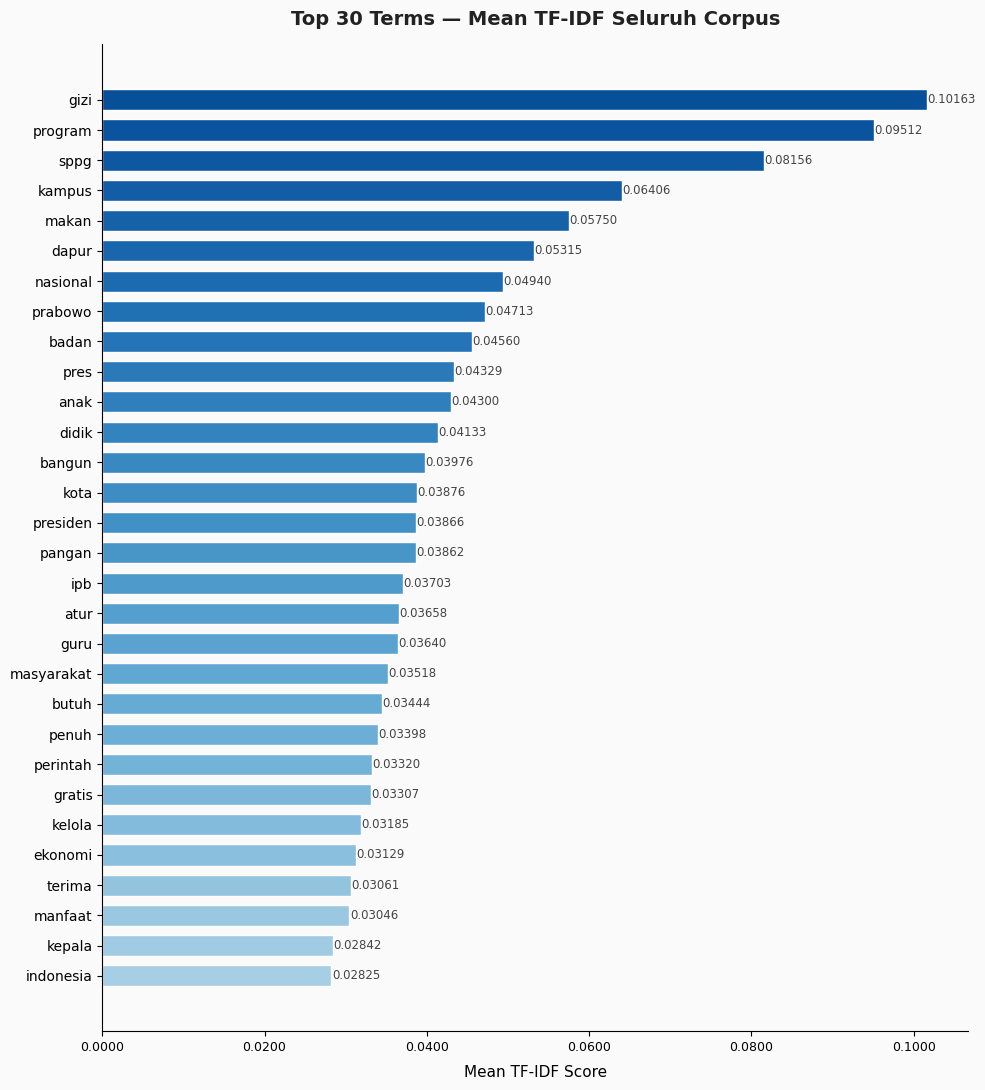

In [65]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, ax = plt.subplots(figsize=(10, 11))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

n = len(top_corpus)
cmap = plt.cm.get_cmap('Blues')
colors = [cmap(0.35 + 0.55 * i / n) for i in range(n)]

bars = ax.barh(
    top_corpus['term'][::-1], top_corpus['mean_tfidf'][::-1],
    color=colors, edgecolor='white', height=0.7
)
for bar, val in zip(bars, top_corpus['mean_tfidf'][::-1]):
    ax.text(
        bar.get_width() + 0.00005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.5f}', va='center', ha='left', fontsize=8.5, color='#444'
    )

ax.set_xlabel('Mean TF-IDF Score', fontsize=11, labelpad=8)
ax.set_title(
    'Top 30 Terms — Mean TF-IDF Seluruh Corpus',
    fontsize=14, fontweight='bold', pad=14, color='#222'
)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
plt.tight_layout()
plt.savefig('output/viz_tfidf_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
# Top word per article (the single most TF-IDF-distinctive word for each article)
top_per_article = []
for i, row in df.iterrows():
    scores = tfidf_corpus[i].toarray().flatten()
    if scores.max() == 0:
        continue
    best_idx = scores.argmax()
    top_per_article.append({
        'judul': row['judul'][:60] + '...' if len(str(row['judul'])) > 60 else row['judul'],
        'sumber': row['sumber'],
        'top_term': features_corpus[best_idx],
        'tfidf': round(float(scores[best_idx]), 4)
    })

df_top_per_article = pd.DataFrame(top_per_article)
print('=== Kata Paling Khas per Artikel (Top TF-IDF Term) ===')
print('\n📊 Cara membaca:')
print('   Setiap baris = satu artikel.')
print('   top_term = kata yang paling MEMBEDAKAN artikel ini dari artikel lain.\n')
display(df_top_per_article)

=== Kata Paling Khas per Artikel (Top TF-IDF Term) ===

📊 Cara membaca:
   Setiap baris = satu artikel.
   top_term = kata yang paling MEMBEDAKAN artikel ini dari artikel lain.



,judul,sumber,top_term,tfidf
0,Prabowo Tanya Buruh di May Day: MBG Bermanfaat...,detikNews,prabowo,0.5223
1,Kampus diminta 'terlibat aktif' bangun dapur M...,BBC,unhas,0.3183
2,"Dukung Kampus Punya Dapur MBG, Mendiktisaintek...",Medcom.id,medcom,0.4588
3,Mendikti Minta Kampus Lain Tiru Langkah Unhas ...,Tempo.co,guru,0.3644
4,Program makan bergizi di Jambi sentuh 446.087 ...,ANTARA News Jambi,jambi,0.6853
5,"Dinilai Pandai Berinovasi, Kota Cilegon Ditunj...",Berita Cilegon,cilegon,0.4553
6,Pemerintah Hapus Program Makan Gratis Hari Sab...,Babel Insight,triliun,0.3433
7,Program Makan Bergizi Gratis Disyukuri Pelajar...,Kemenko Polkam R.I.,sorong,0.3841
8,Rektor IPB Respons Positif Dorongan BGN Agar P...,CNN Indonesia,kampus,0.3820
9,IPB siap bangun SPPG di Bogor Mei ini untuk du...,ANTARA News,ipb,0.4270


---
## POS Analysis — Seluruh Corpus

Menggabungkan token POS dari **semua artikel** (tanpa pengelompokan)
untuk melihat kata benda, kata kerja, dan kata sifat yang paling dominan
dalam keseluruhan pemberitaan MBG.

In [52]:
from collections import Counter

# ── NOUN ──────────────────────────────────────────────────────────────────────
all_nouns = ' '.join(df['pos_noun'].fillna('').tolist())
noun_freq = Counter(all_nouns.split())
top_nouns = pd.DataFrame(noun_freq.most_common(30), columns=['kata_benda', 'frekuensi'])
top_nouns.insert(0, 'rank', range(1, len(top_nouns) + 1))

print('=== Top 30 Kata Benda (NOUN) — Seluruh Corpus ===')
print('Kata benda yang paling sering muncul di seluruh artikel MBG:\n')
display(top_nouns)

=== Top 30 Kata Benda (NOUN) — Seluruh Corpus ===
Kata benda yang paling sering muncul di seluruh artikel MBG:



,rank,kata_benda,frekuensi
0,1,gizi,170
1,2,program,160
2,3,mbg,119
3,4,sppg,99
4,5,makan,86
5,6,tahun,81
6,7,nasional,71
7,8,badan,69
8,9,bgn,61
9,10,dapur,53


In [67]:
# ── VERB ──────────────────────────────────────────────────────────────────────
all_verbs = ' '.join(df['pos_verb'].fillna('').tolist())
verb_freq = Counter(all_verbs.split())
top_verbs = pd.DataFrame(verb_freq.most_common(30), columns=['kata_kerja', 'frekuensi'])
top_verbs.insert(0, 'rank', range(1, len(top_verbs) + 1))

print('=== Top 30 Kata Kerja (VERB) — Seluruh Corpus ===')
print('Aksi/proses yang paling sering dibahas dalam pemberitaan MBG:\n')
display(top_verbs)

=== Top 30 Kata Kerja (VERB) — Seluruh Corpus ===
Aksi/proses yang paling sering dibahas dalam pemberitaan MBG:



,rank,kata_kerja,frekuensi
0,1,jadi,59
1,2,ada,41
2,3,kata,35
3,4,laku,30
4,5,beri,29
5,6,milik,22
6,7,bangun,20
7,8,jalan,20
8,9,mulai,20
9,10,butuh,19


In [54]:
# ── ADJ ───────────────────────────────────────────────────────────────────────
all_adjs = ' '.join(df['pos_adj'].fillna('').tolist())
adj_freq = Counter(all_adjs.split())
top_adjs = pd.DataFrame(adj_freq.most_common(30), columns=['kata_sifat', 'frekuensi'])
top_adjs.insert(0, 'rank', range(1, len(top_adjs) + 1))

print('=== Top 30 Kata Sifat (ADJ) — Seluruh Corpus ===')
print('Kata sifat mencerminkan tone/framing pemberitaan MBG:\n')
display(top_adjs)

=== Top 30 Kata Sifat (ADJ) — Seluruh Corpus ===
Kata sifat mencerminkan tone/framing pemberitaan MBG:



,rank,kata_sifat,frekuensi
0,1,tinggi,28
1,2,gratis,20
2,3,langsung,19
3,4,besar,17
4,5,operasional,16
5,6,lain,15
6,7,lokal,13
7,8,penting,12
8,9,hamil,12
9,10,nasional,12


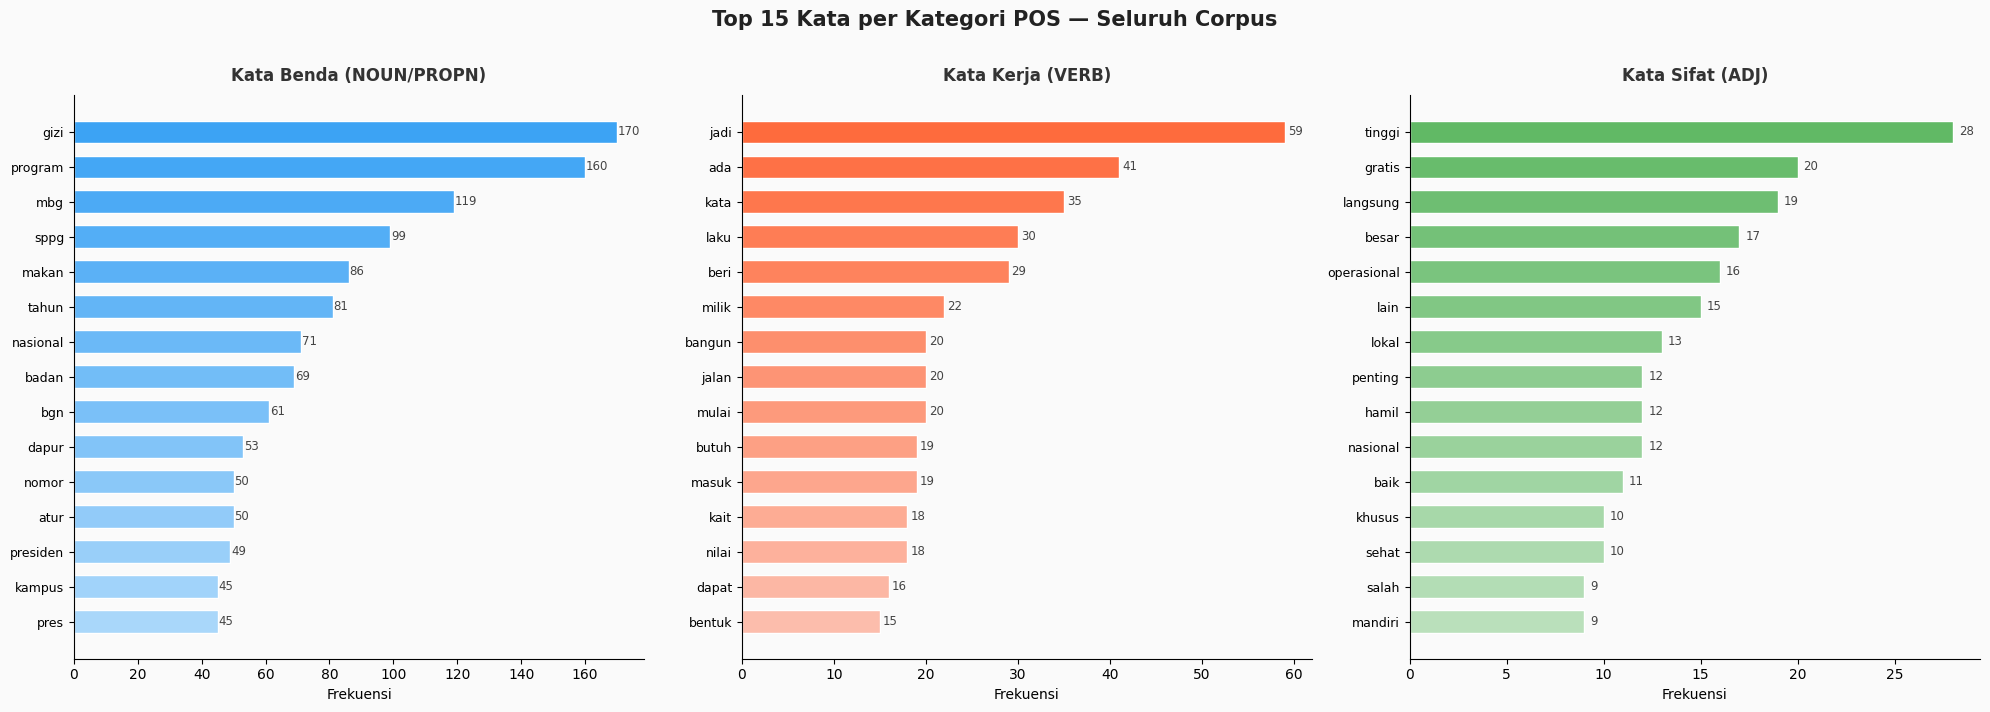

In [68]:
top_n_pos = 15  # how many to show per POS

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(
    'Top 15 Kata per Kategori POS — Seluruh Corpus',
    fontsize=15, fontweight='bold', y=1.01, color='#222'
)

pos_data = [
    (top_nouns.head(top_n_pos), 'kata_benda',  'Kata Benda (NOUN/PROPN)', '#2196F3'),
    (top_verbs.head(top_n_pos), 'kata_kerja',  'Kata Kerja (VERB)',        '#FF5722'),
    (top_adjs.head(top_n_pos),  'kata_sifat',  'Kata Sifat (ADJ)',         '#4CAF50'),
]

for ax, (df_pos, col, title, base_color) in zip(axes, pos_data):
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        'custom', ['#E3F2FD' if base_color == '#2196F3'
                   else '#FBE9E7' if base_color == '#FF5722'
                   else '#E8F5E9', base_color]
    )
    n_bars = len(df_pos)
    bar_colors = [cmap(0.3 + 0.6 * i / n_bars) for i in range(n_bars)]

    bars = ax.barh(
        df_pos[col][::-1], df_pos['frekuensi'][::-1],
        color=bar_colors, edgecolor='white', height=0.65
    )
    for bar, val in zip(bars, df_pos['frekuensi'][::-1].values):
        ax.text(
            bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(int(val)), va='center', ha='left', fontsize=8.5, color='#444'
        )
    ax.set_title(title, fontsize=12, fontweight='bold', color='#333', pad=10)
    ax.set_xlabel('Frekuensi', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('output/viz_pos_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

In [69]:
# TF-IDF on NOUN tokens per article (corpus-wide, not grouped)
noun_texts = df['pos_noun'].fillna('').tolist()
noun_texts_valid = [t for t in noun_texts if t.strip()]

if noun_texts_valid:
    vec_noun = TfidfVectorizer()
    mat_noun = vec_noun.fit_transform(noun_texts)
    feat_noun = vec_noun.get_feature_names_out()
    mean_noun = np.asarray(mat_noun.mean(axis=0)).flatten()
    top_n_idx = mean_noun.argsort()[::-1][:20]
    tfidf_noun_df = pd.DataFrame({
        'rank': range(1, 21),
        'noun_term': feat_noun[top_n_idx],
        'mean_tfidf': mean_noun[top_n_idx].round(5)
    })
    print('=== Top 20 Kata Benda — Mean TF-IDF (corpus-wide) ===')
    display(tfidf_noun_df)

=== Top 20 Kata Benda — Mean TF-IDF (corpus-wide) ===


,rank,noun_term,mean_tfidf
0,1,gizi,0.09489
1,2,program,0.09471
2,3,mbg,0.08387
3,4,sppg,0.08228
4,5,kampus,0.06146
5,6,makan,0.05973
6,7,bgn,0.05748
7,8,dapur,0.05065
8,9,prabowo,0.04860
9,10,tahun,0.04736


---
## NER Analysis — Seluruh Corpus

Menggabungkan semua entitas bernama dari **seluruh artikel** untuk melihat
tokoh, organisasi, dan lokasi yang paling dominan dalam pemberitaan MBG secara keseluruhan.

In [70]:
# ── PER ───────────────────────────────────────────────────────────────────────
all_per = ' '.join(df['ner_per'].fillna('').tolist())
per_freq = Counter(all_per.split())
top_per = pd.DataFrame(per_freq.most_common(20), columns=['tokoh', 'frekuensi'])
top_per['tokoh'] = top_per['tokoh'].str.replace('_', ' ')
top_per.insert(0, 'rank', range(1, len(top_per) + 1))

print('=== Top 20 Tokoh (PER) — Seluruh Corpus ===')
print('Nama orang yang paling sering disebut di seluruh artikel MBG:\n')
display(top_per)

=== Top 20 Tokoh (PER) — Seluruh Corpus ===
Nama orang yang paling sering disebut di seluruh artikel MBG:



,rank,tokoh,frekuensi
0,1,prabowo,12
1,2,alim,6
2,3,dadan hindayana,5
3,4,jokowi,4
4,5,prabowo subianto,3
5,6,brian,3
6,7,alim setiawan slamet,3
7,8,brian yuliarto,2
8,9,helldy agustian,2
9,10,juda agung,2


In [71]:
# ── ORG ───────────────────────────────────────────────────────────────────────
all_org = ' '.join(df['ner_org'].fillna('').tolist())
org_freq = Counter(all_org.split())
top_org = pd.DataFrame(org_freq.most_common(20), columns=['organisasi', 'frekuensi'])
top_org['organisasi'] = top_org['organisasi'].str.replace('_', ' ')
top_org.insert(0, 'rank', range(1, len(top_org) + 1))

print('=== Top 20 Organisasi (ORG) — Seluruh Corpus ===')
print('Lembaga/organisasi yang paling sering disebut dalam pemberitaan MBG:\n')
display(top_org)

=== Top 20 Organisasi (ORG) — Seluruh Corpus ===
Lembaga/organisasi yang paling sering disebut dalam pemberitaan MBG:



,rank,organisasi,frekuensi
0,1,bgn,13
1,2,kampus,10
2,3,badan gizi nasional,9
3,4,ipb,7
4,5,satuan pelayanan pemenuhan gizi,6
5,6,mbg,5
6,7,spp,5
7,8,sppg,3
8,9,antara,3
9,10,yayasan,3


In [72]:
# ── LOC ───────────────────────────────────────────────────────────────────────
all_loc = ' '.join(df['ner_loc'].fillna('').tolist())
loc_freq = Counter(all_loc.split())
top_loc = pd.DataFrame(loc_freq.most_common(20), columns=['lokasi', 'frekuensi'])
top_loc['lokasi'] = top_loc['lokasi'].str.replace('_', ' ')
top_loc.insert(0, 'rank', range(1, len(top_loc) + 1))

print('=== Top 20 Lokasi (LOC) — Seluruh Corpus ===')
print('Wilayah/tempat yang paling sering disebut dalam pemberitaan MBG:\n')
display(top_loc)

=== Top 20 Lokasi (LOC) — Seluruh Corpus ===
Wilayah/tempat yang paling sering disebut dalam pemberitaan MBG:



,rank,lokasi,frekuensi
0,1,cilegon,2
1,2,gedung erbe hall,2
2,3,monas,1
3,4,versi,1
4,5,hasanuddin,1
5,6,loa,1
6,7,ruang rapat,1
7,8,hotel borobudur,1
8,9,lapangan monas,1
9,10,rumah,1


In [73]:
# ── MISC ──────────────────────────────────────────────────────────────────────
all_misc = ' '.join(df['ner_misc'].fillna('').tolist())
misc_freq = Counter(all_misc.split())
top_misc = pd.DataFrame(misc_freq.most_common(20), columns=['misc_entity', 'frekuensi'])
top_misc['misc_entity'] = top_misc['misc_entity'].str.replace('_', ' ')
top_misc.insert(0, 'rank', range(1, len(top_misc) + 1))

print('=== Top 20 MISC — Seluruh Corpus ===')
print('Entitas lain (nama program, undang-undang, istilah teknis):\n')
display(top_misc)

=== Top 20 MISC — Seluruh Corpus ===
Entitas lain (nama program, undang-undang, istilah teknis):



,rank,misc_entity,frekuensi


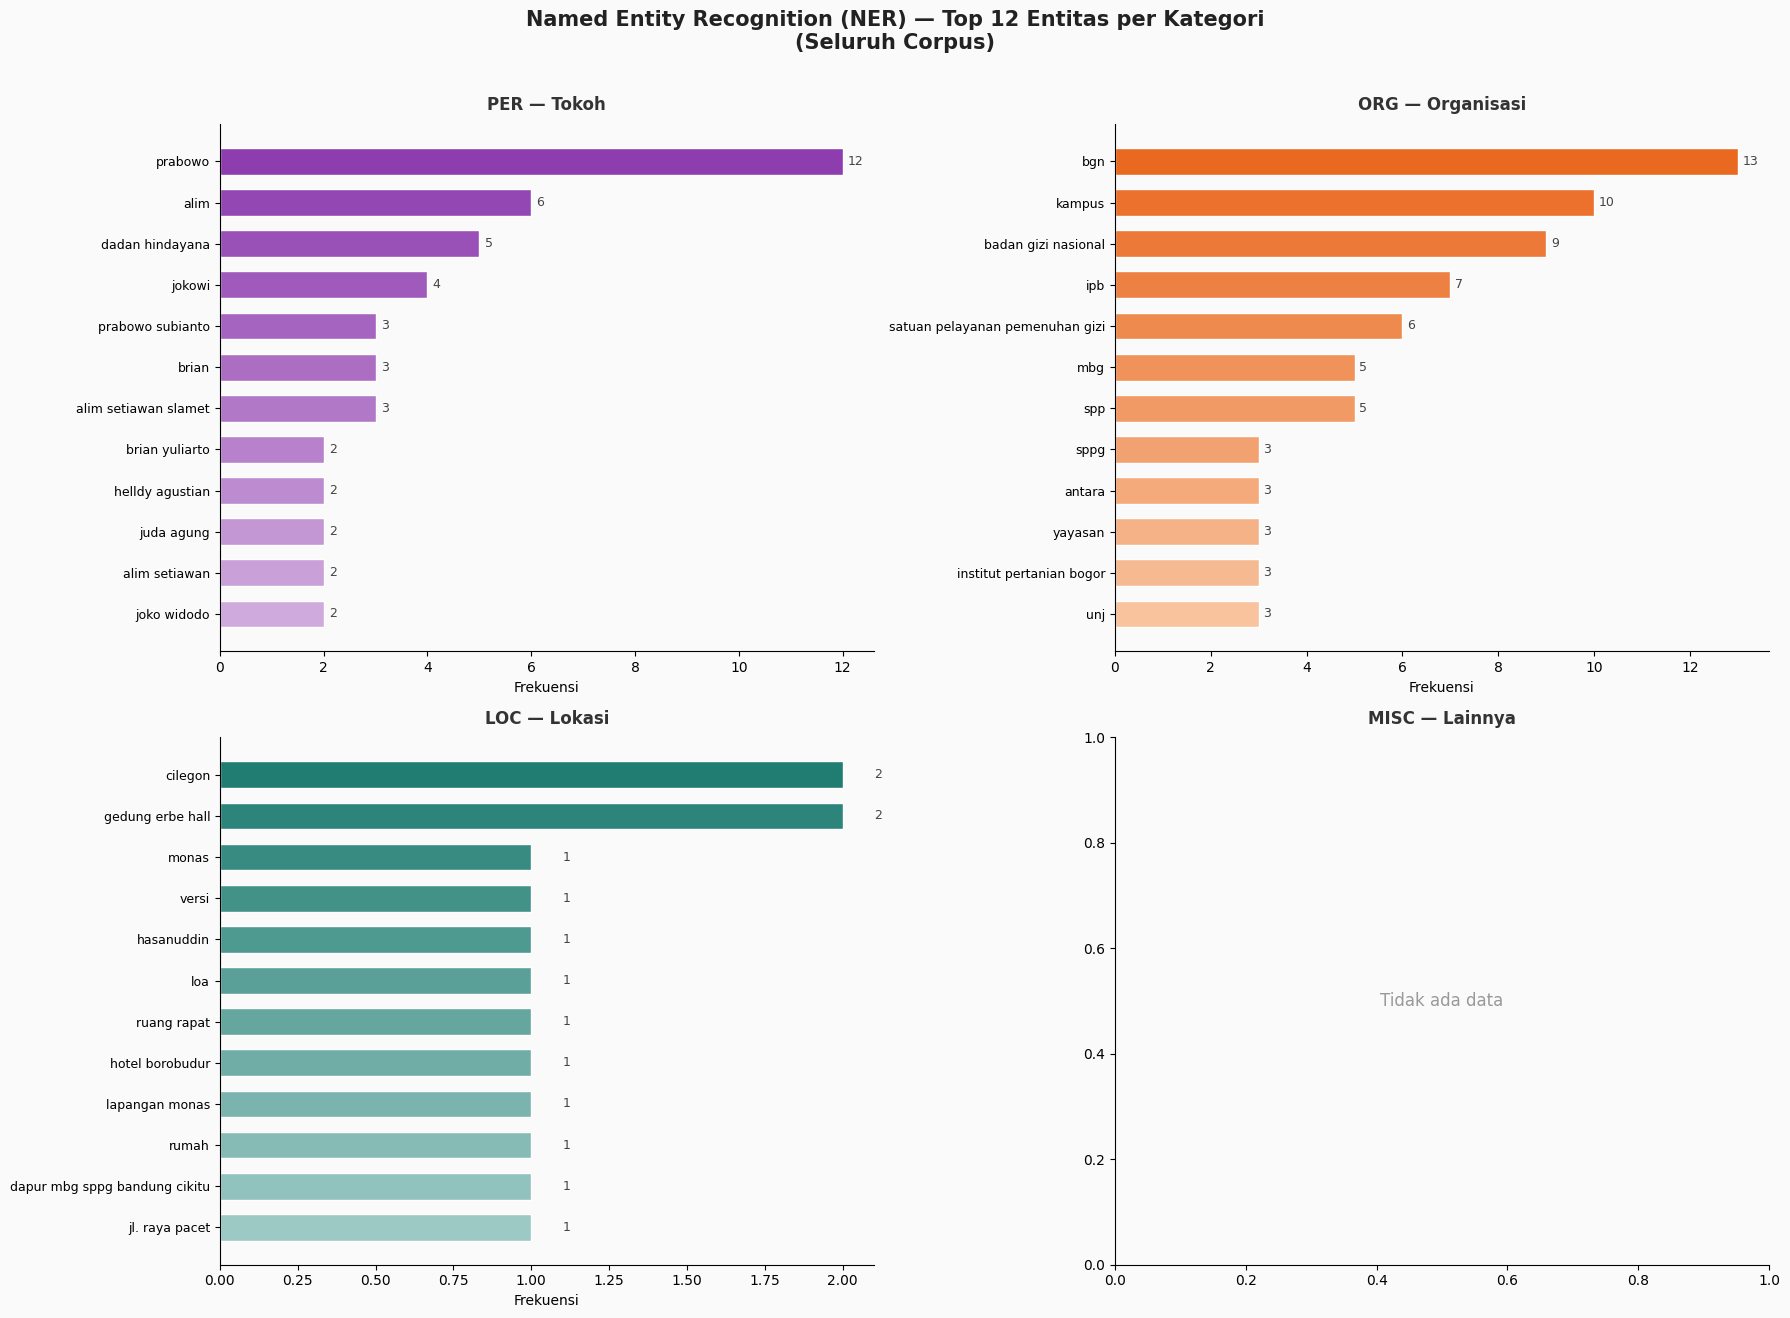

In [74]:
top_n_ner = 12

ner_data = [
    (top_per.head(top_n_ner),  'tokoh',       'PER — Tokoh',        '#7B1FA2', '#F3E5F5'),
    (top_org.head(top_n_ner),  'organisasi',  'ORG — Organisasi',   '#E65100', '#FFF3E0'),
    (top_loc.head(top_n_ner),  'lokasi',      'LOC — Lokasi',       '#00695C', '#E0F2F1'),
    (top_misc.head(top_n_ner), 'misc_entity', 'MISC — Lainnya',     '#1565C0', '#E3F2FD'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(
    'Named Entity Recognition (NER) — Top 12 Entitas per Kategori\n(Seluruh Corpus)',
    fontsize=15, fontweight='bold', y=1.01, color='#222'
)
axes_flat = axes.flatten()

for ax, (df_ner, col, title, dark_c, light_c) in zip(axes_flat, ner_data):
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if df_ner.empty or df_ner['frekuensi'].sum() == 0:
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='#999')
        ax.set_title(title, fontsize=12, fontweight='bold', color='#333', pad=10)
        continue

    cmap_ner = plt.cm.colors.LinearSegmentedColormap.from_list('ner', [light_c, dark_c])
    n_bars = len(df_ner)
    bar_colors = [cmap_ner(0.3 + 0.6 * i / n_bars) for i in range(n_bars)]

    bars = ax.barh(
        df_ner[col][::-1], df_ner['frekuensi'][::-1],
        color=bar_colors, edgecolor='white', height=0.65
    )
    for bar, val in zip(bars, df_ner['frekuensi'][::-1].values):
        ax.text(
            bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(int(val)), va='center', ha='left', fontsize=9, color='#444'
        )
    ax.set_title(title, fontsize=12, fontweight='bold', color='#333', pad=10)
    ax.set_xlabel('Frekuensi', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('output/viz_ner_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

---
## N-Grams — Seluruh Corpus

Mencari **frasa multi-kata** yang paling sering dan paling distingtif
di seluruh corpus artikel MBG, menggunakan Mean TF-IDF corpus-wide.

In [76]:
# ── Bigram corpus-wide ────────────────────────────────────────────────────────
vec_bg = TfidfVectorizer(ngram_range=(2, 2))
mat_bg = vec_bg.fit_transform(df['after_lemmatization'].fillna(''))
feat_bg = vec_bg.get_feature_names_out()
mean_bg = np.asarray(mat_bg.mean(axis=0)).flatten()
top_bg_idx = mean_bg.argsort()[::-1][:25]

top_bigram_corpus = pd.DataFrame({
    'rank': range(1, 26),
    'bigram': feat_bg[top_bg_idx],
    'mean_tfidf': mean_bg[top_bg_idx].round(5)
})

print('=== Top 25 Bigram — Mean TF-IDF Seluruh Corpus ===')
print('Frasa 2 kata yang paling distingtif di keseluruhan corpus:\n')
display(top_bigram_corpus)

=== Top 25 Bigram — Mean TF-IDF Seluruh Corpus ===
Frasa 2 kata yang paling distingtif di keseluruhan corpus:



,rank,bigram,mean_tfidf
0,1,gizi nasional,0.03874
1,2,badan gizi,0.03623
2,3,makan gizi,0.03479
3,4,gizi gratis,0.03037
4,5,program makan,0.02734
5,6,penuh gizi,0.02371
6,7,terima manfaat,0.02258
7,8,anak anak,0.02175
8,9,gizi sppg,0.01858
9,10,atur presiden,0.01839


In [77]:
# ── Trigram corpus-wide ───────────────────────────────────────────────────────
vec_tg = TfidfVectorizer(ngram_range=(3, 3))
mat_tg = vec_tg.fit_transform(df['after_lemmatization'].fillna(''))
feat_tg = vec_tg.get_feature_names_out()
mean_tg = np.asarray(mat_tg.mean(axis=0)).flatten()
top_tg_idx = mean_tg.argsort()[::-1][:25]

top_trigram_corpus = pd.DataFrame({
    'rank': range(1, 26),
    'trigram': feat_tg[top_tg_idx],
    'mean_tfidf': mean_tg[top_tg_idx].round(5)
})

print('=== Top 25 Trigram — Mean TF-IDF Seluruh Corpus ===')
print('Frasa 3 kata yang paling distingtif di keseluruhan corpus:\n')
display(top_trigram_corpus)

=== Top 25 Trigram — Mean TF-IDF Seluruh Corpus ===
Frasa 3 kata yang paling distingtif di keseluruhan corpus:



,rank,trigram,mean_tfidf
0,1,badan gizi nasional,0.03577
1,2,makan gizi gratis,0.02999
2,3,program makan gizi,0.02351
3,4,layan penuh gizi,0.01706
4,5,penuh gizi sppg,0.01706
5,6,temu lokasi coba,0.01562
6,7,coba salah taut,0.01562
7,8,lokasi coba salah,0.01562
8,9,salah taut cari,0.01562
9,10,makan siang gratis,0.01503


In [78]:
# ── Raw frequency of bigrams (tanpa TF-IDF weighting) ────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

cv_bg = CountVectorizer(ngram_range=(2, 2))
count_mat = cv_bg.fit_transform(df['after_lemmatization'].fillna(''))
count_feat = cv_bg.get_feature_names_out()
total_counts = np.asarray(count_mat.sum(axis=0)).flatten()
top_count_idx = total_counts.argsort()[::-1][:25]

top_bigram_freq = pd.DataFrame({
    'rank': range(1, 26),
    'bigram': count_feat[top_count_idx],
    'frekuensi': total_counts[top_count_idx]
})

print('=== Top 25 Bigram — Frekuensi Murni (Count) Seluruh Corpus ===')
print('\n📊 Perbedaan vs TF-IDF:')
print('   Count = frekuensi mentah, tidak mempertimbangkan seberapa umum frasa itu')
print('   TF-IDF = mempertimbangkan keunikan frasa antar artikel\n')
display(top_bigram_freq)

=== Top 25 Bigram — Frekuensi Murni (Count) Seluruh Corpus ===

📊 Perbedaan vs TF-IDF:
   Count = frekuensi mentah, tidak mempertimbangkan seberapa umum frasa itu
   TF-IDF = mempertimbangkan keunikan frasa antar artikel



,rank,bigram,frekuensi
0,1,gizi nasional,66
1,2,badan gizi,62
2,3,makan gizi,49
3,4,gizi gratis,44
4,5,terima manfaat,42
5,6,program makan,36
6,7,atur presiden,32
7,8,penuh gizi,30
8,9,manfaat program,27
9,10,program strategis,26


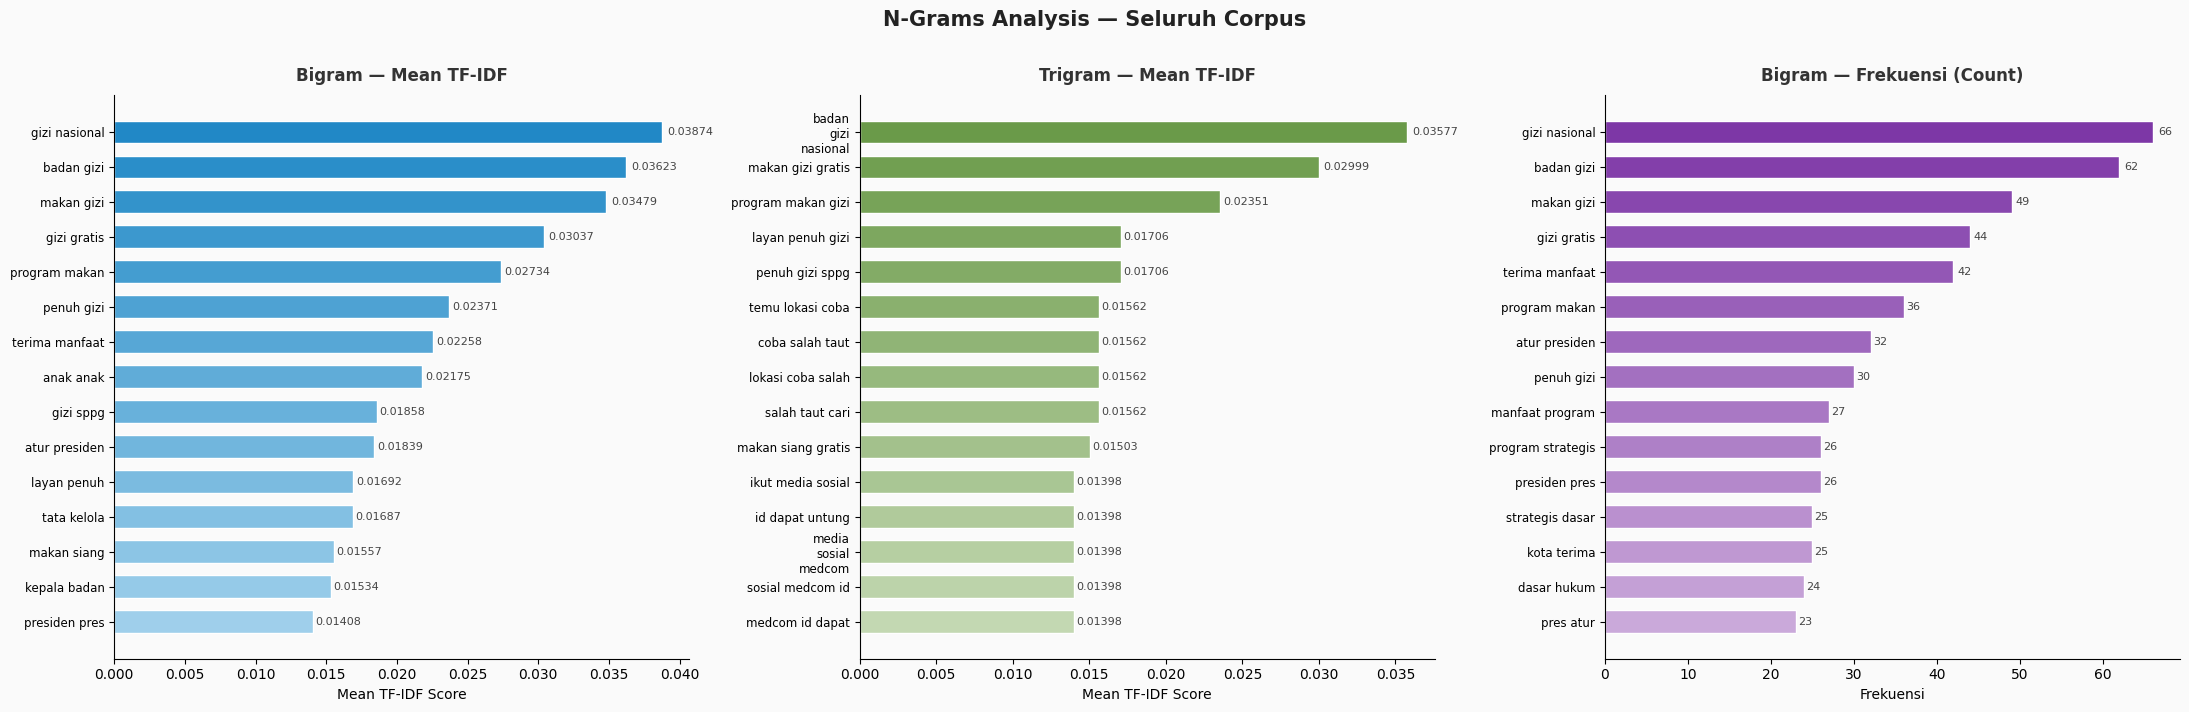

In [79]:
top_n_ng = 15

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(
    'N-Grams Analysis — Seluruh Corpus',
    fontsize=15, fontweight='bold', y=1.01, color='#222'
)

ng_data = [
    (top_bigram_corpus.head(top_n_ng),  'bigram',  'mean_tfidf',
     'Bigram — Mean TF-IDF',   '#0277BD', '#E1F5FE'),
    (top_trigram_corpus.head(top_n_ng), 'trigram', 'mean_tfidf',
     'Trigram — Mean TF-IDF',  '#558B2F', '#F1F8E9'),
    (top_bigram_freq.head(top_n_ng),    'bigram',  'frekuensi',
     'Bigram — Frekuensi (Count)', '#6A1B9A', '#F3E5F5'),
]

for ax, (df_ng, term_col, val_col, title, dark_c, light_c) in zip(axes, ng_data):
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    cmap_ng = plt.cm.colors.LinearSegmentedColormap.from_list('ng', [light_c, dark_c])
    n_bars = len(df_ng)
    bar_colors = [cmap_ng(0.3 + 0.6 * i / n_bars) for i in range(n_bars)]

    # Wrap long n-gram labels
    labels = [t.replace(' ', '\n') if len(t) > 18 else t
              for t in df_ng[term_col][::-1]]

    bars = ax.barh(
        labels, df_ng[val_col][::-1].values,
        color=bar_colors, edgecolor='white', height=0.65
    )
    for bar, val in zip(bars, df_ng[val_col][::-1].values):
        label = f'{val:.5f}' if val < 1 else str(int(val))
        ax.text(
            bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            label, va='center', ha='left', fontsize=8, color='#444'
        )
    ax.set_title(title, fontsize=12, fontweight='bold', color='#333', pad=10)
    x_label = 'Mean TF-IDF Score' if val_col == 'mean_tfidf' else 'Frekuensi'
    ax.set_xlabel(x_label, fontsize=10)
    ax.tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.savefig('output/viz_ngram_corpus.png', dpi=150, bbox_inches='tight')
plt.show()